In [1]:
import numpy as np
import matplotlib.pyplot as plt

import mpl_config
import ode_models as odes

### Set up and solve ODE model

In [2]:
alpha = 1.5
beta = 1
delta = 1
gamma = 3
x0 = 1
y0 = 1
t = np.linspace(0, 20, 500)
X0 = [x0, y0]

lotkavolterra = odes.LotkaVolterra([alpha, beta, delta, gamma])
solution = lotkavolterra.solve(initial_conditions=X0, timepoints=t)

### Plot ODE solution

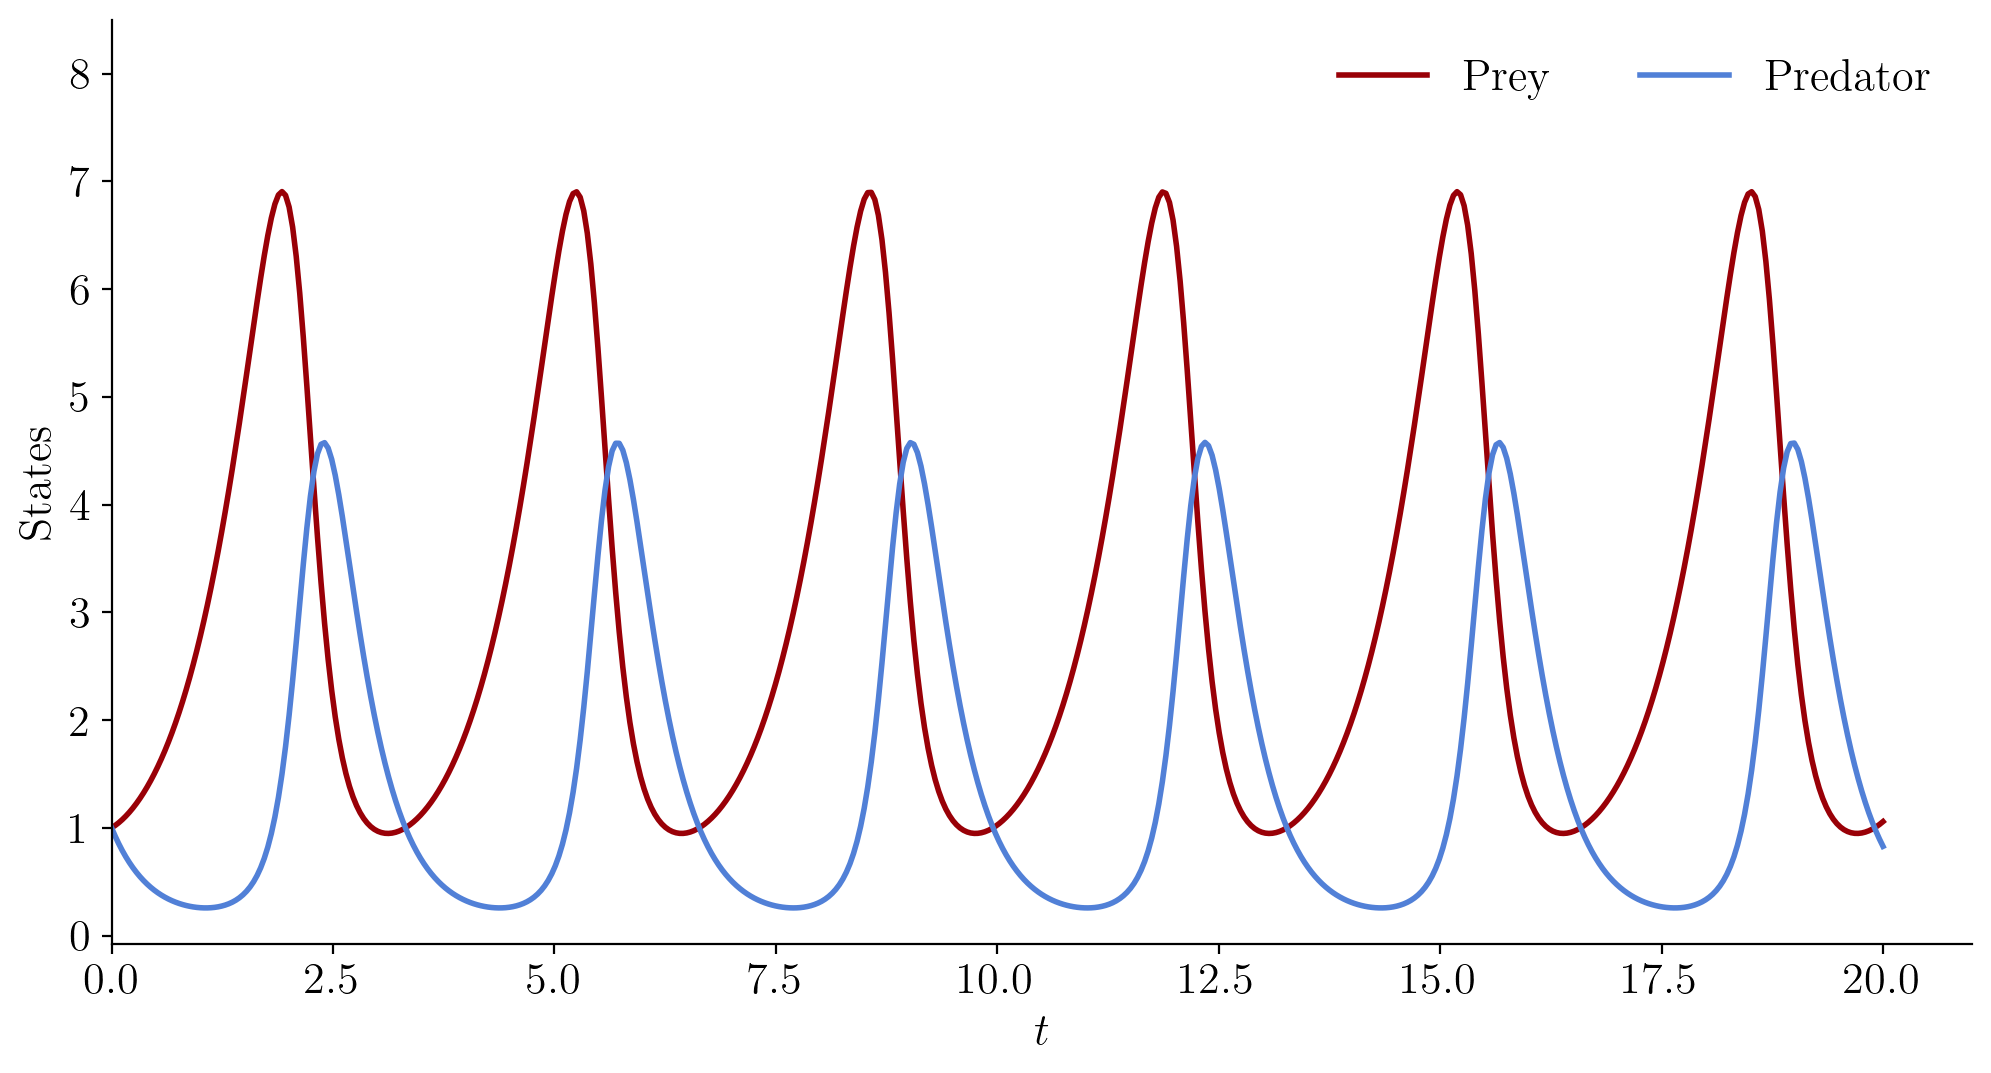

In [3]:
_, ax = lotkavolterra.plot(t, solution, ls="-")
ax.set_ylim(top=8.5)
ax.legend(loc="upper right", ncol=2)
plt.show()

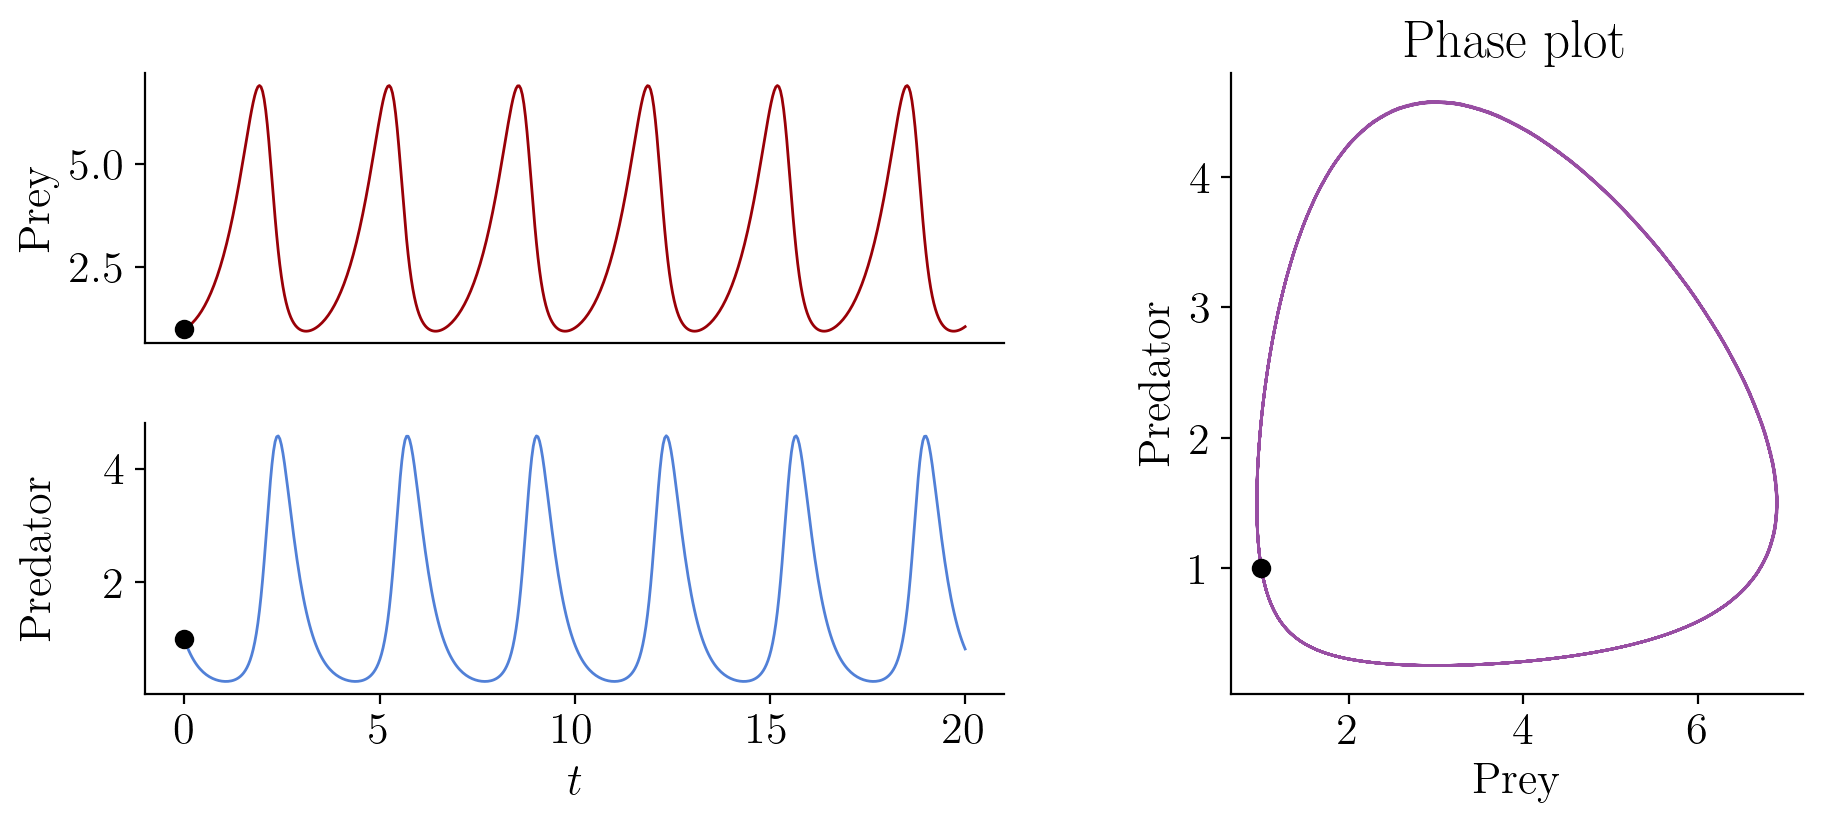

In [4]:
lotkavolterra.plot_phase(t, solution)
plt.show()

### Plot noised solutions

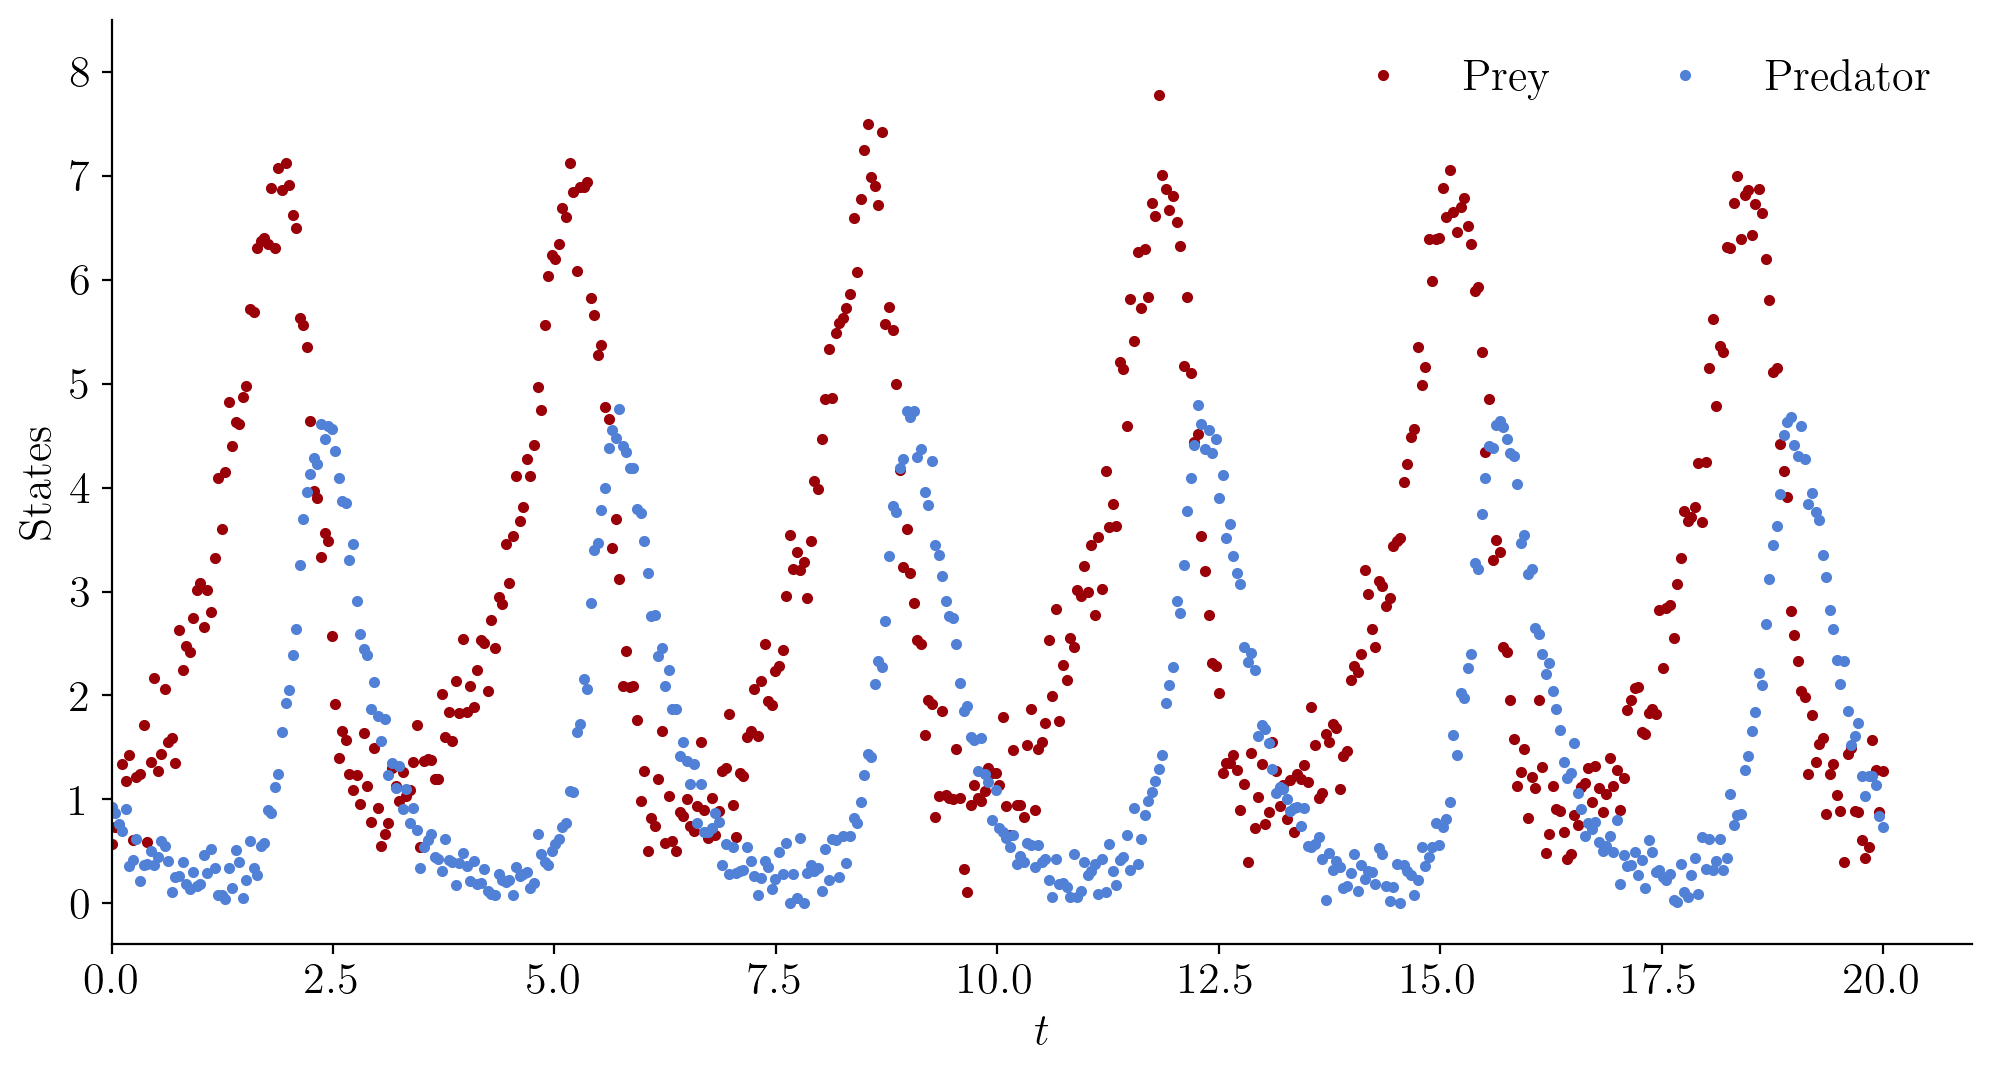

In [5]:
# TODO - Look into how much this noise is 
_, ax = lotkavolterra.plot(t, lotkavolterra.noise(solution, 0.10))
ax.set_ylim(top=8.5)
ax.legend(loc="upper right", ncol=2)
plt.show()

### Helpers and Classes

In [6]:
# Create Model Class
import gpytorch
import torch
import matplotlib.pyplot as plt
import numpy as np

from gpytorch.models import ExactGP
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.means import ZeroMean, ConstantMean
from gpytorch.kernels import *

class GP(ExactGP):
    def __init__(self, train_x, train_y, likelihood, mean, kernel,
                 constant_bounds=None, length_scale_bounds=None,):
        super(GP, self).__init__(train_x, train_y, likelihood)
        self.mean_module = mean
        self.covar_module = kernel
    
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x,covar_x)


def train(model, train_x, train_y, training_iter=50, lr = 0.1):
    # Set into training mode
    model.train()
    model.likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(model.likelihood, model)

    # Train over several iterations using the full training dataset each time
    for i in range(training_iter):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        # print('Iter %d/%d - Loss: %.3f   lengthscale: %.3f   noise: %.3f' % (
        #     i + 1, training_iter, loss.item(),
        #     model.covar_module.base_kernel.lengthscale.item(),
        #     model.likelihood.noise.item()
        # ))
        optimizer.step()

def display(train_x, train_y, test_x, test_y, model, title = "Title Placeholder", underlying = False):
    model.eval()
    # Get predictions
    with torch.no_grad():
        y = model(test_x)
        ly = model.likelihood(y)
        mean_ly = ly.mean
        std_ly = ly.stddev

        # Initialize plot
        f, ax = plt.subplots(1, 1, figsize=(16, 12))

        # Get upper and lower confidence bounds
        lower, upper = ly.confidence_region()
        # Plot training data as black stars
        ax.plot(train_x.numpy(), train_y.numpy(), 'k*', zorder=10)
        # Plot predictive means as blue line
        ax.plot(test_x.numpy(), ly.mean.numpy(), 'b', lw=2)
        # Shade between the lower and upper confidence bounds
        ax.fill_between(test_x.numpy(), lower.numpy(), upper.numpy(), alpha=0.5, color='royalblue')
        # ax.set_ylim([-3, 3])
        if underlying:
            ax.plot(test_x.numpy(), test_y.numpy(), 'crimson', lw=2)
            ax.legend(['Observed Data', 'Mean', 'Confidence', 'Underlying Data'])
        else:
            ax.legend(['Observed Data', 'Mean', 'Confidence'])
        ax.grid(True)
        ax.set_title(title)

def uniformly_sparsify(x, y, factor=10):
    """Select every factor-th data point."""
    return x[::factor], y[::factor]

# def randomly_sparsify(x, y, num_points=50):
#     """Randomly select num_points data points."""
#     # Get a random permutation of indices and select the first num_points, then sort the indices.
#     indices = torch.randperm(x.size(0))[:num_points].sort().values
#     return x[indices], y[indices]

def randomly_sparsify(*tensors, num_points=50):
    if not tensors:
        raise ValueError("At least one tensor must be provided.")
        
    # Use the first tensor to determine the number of data points.
    num_data = tensors[0].size(0)
    
    # Ensure that all tensors have the same first dimension length.
    for t in tensors:
        if t.size(0) != num_data:
            raise ValueError("All tensors must have the same number of data points in the first dimension.")
    
    # Generate sorted random indices.
    indices = torch.randperm(num_data)[:num_points].sort().values
    return tuple(tensor[indices] for tensor in tensors)

### Data

In [7]:
predator_noisy, prey_noisy = torch.from_numpy(lotkavolterra.noise(solution, 0.10)[1]), torch.from_numpy(lotkavolterra.noise(solution, 0.10)[0])

time = torch.from_numpy(t)
predator_noisy.dtype, predator_noisy.shape, prey_noisy.dtype, prey_noisy.shape, time.dtype, time.shape

(torch.float64,
 torch.Size([500]),
 torch.float64,
 torch.Size([500]),
 torch.float64,
 torch.Size([500]))

### RBF Prediction Over all data

/Users/anthonypoole/miniconda3/envs/gpbayesopinf/lib/python3.12/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


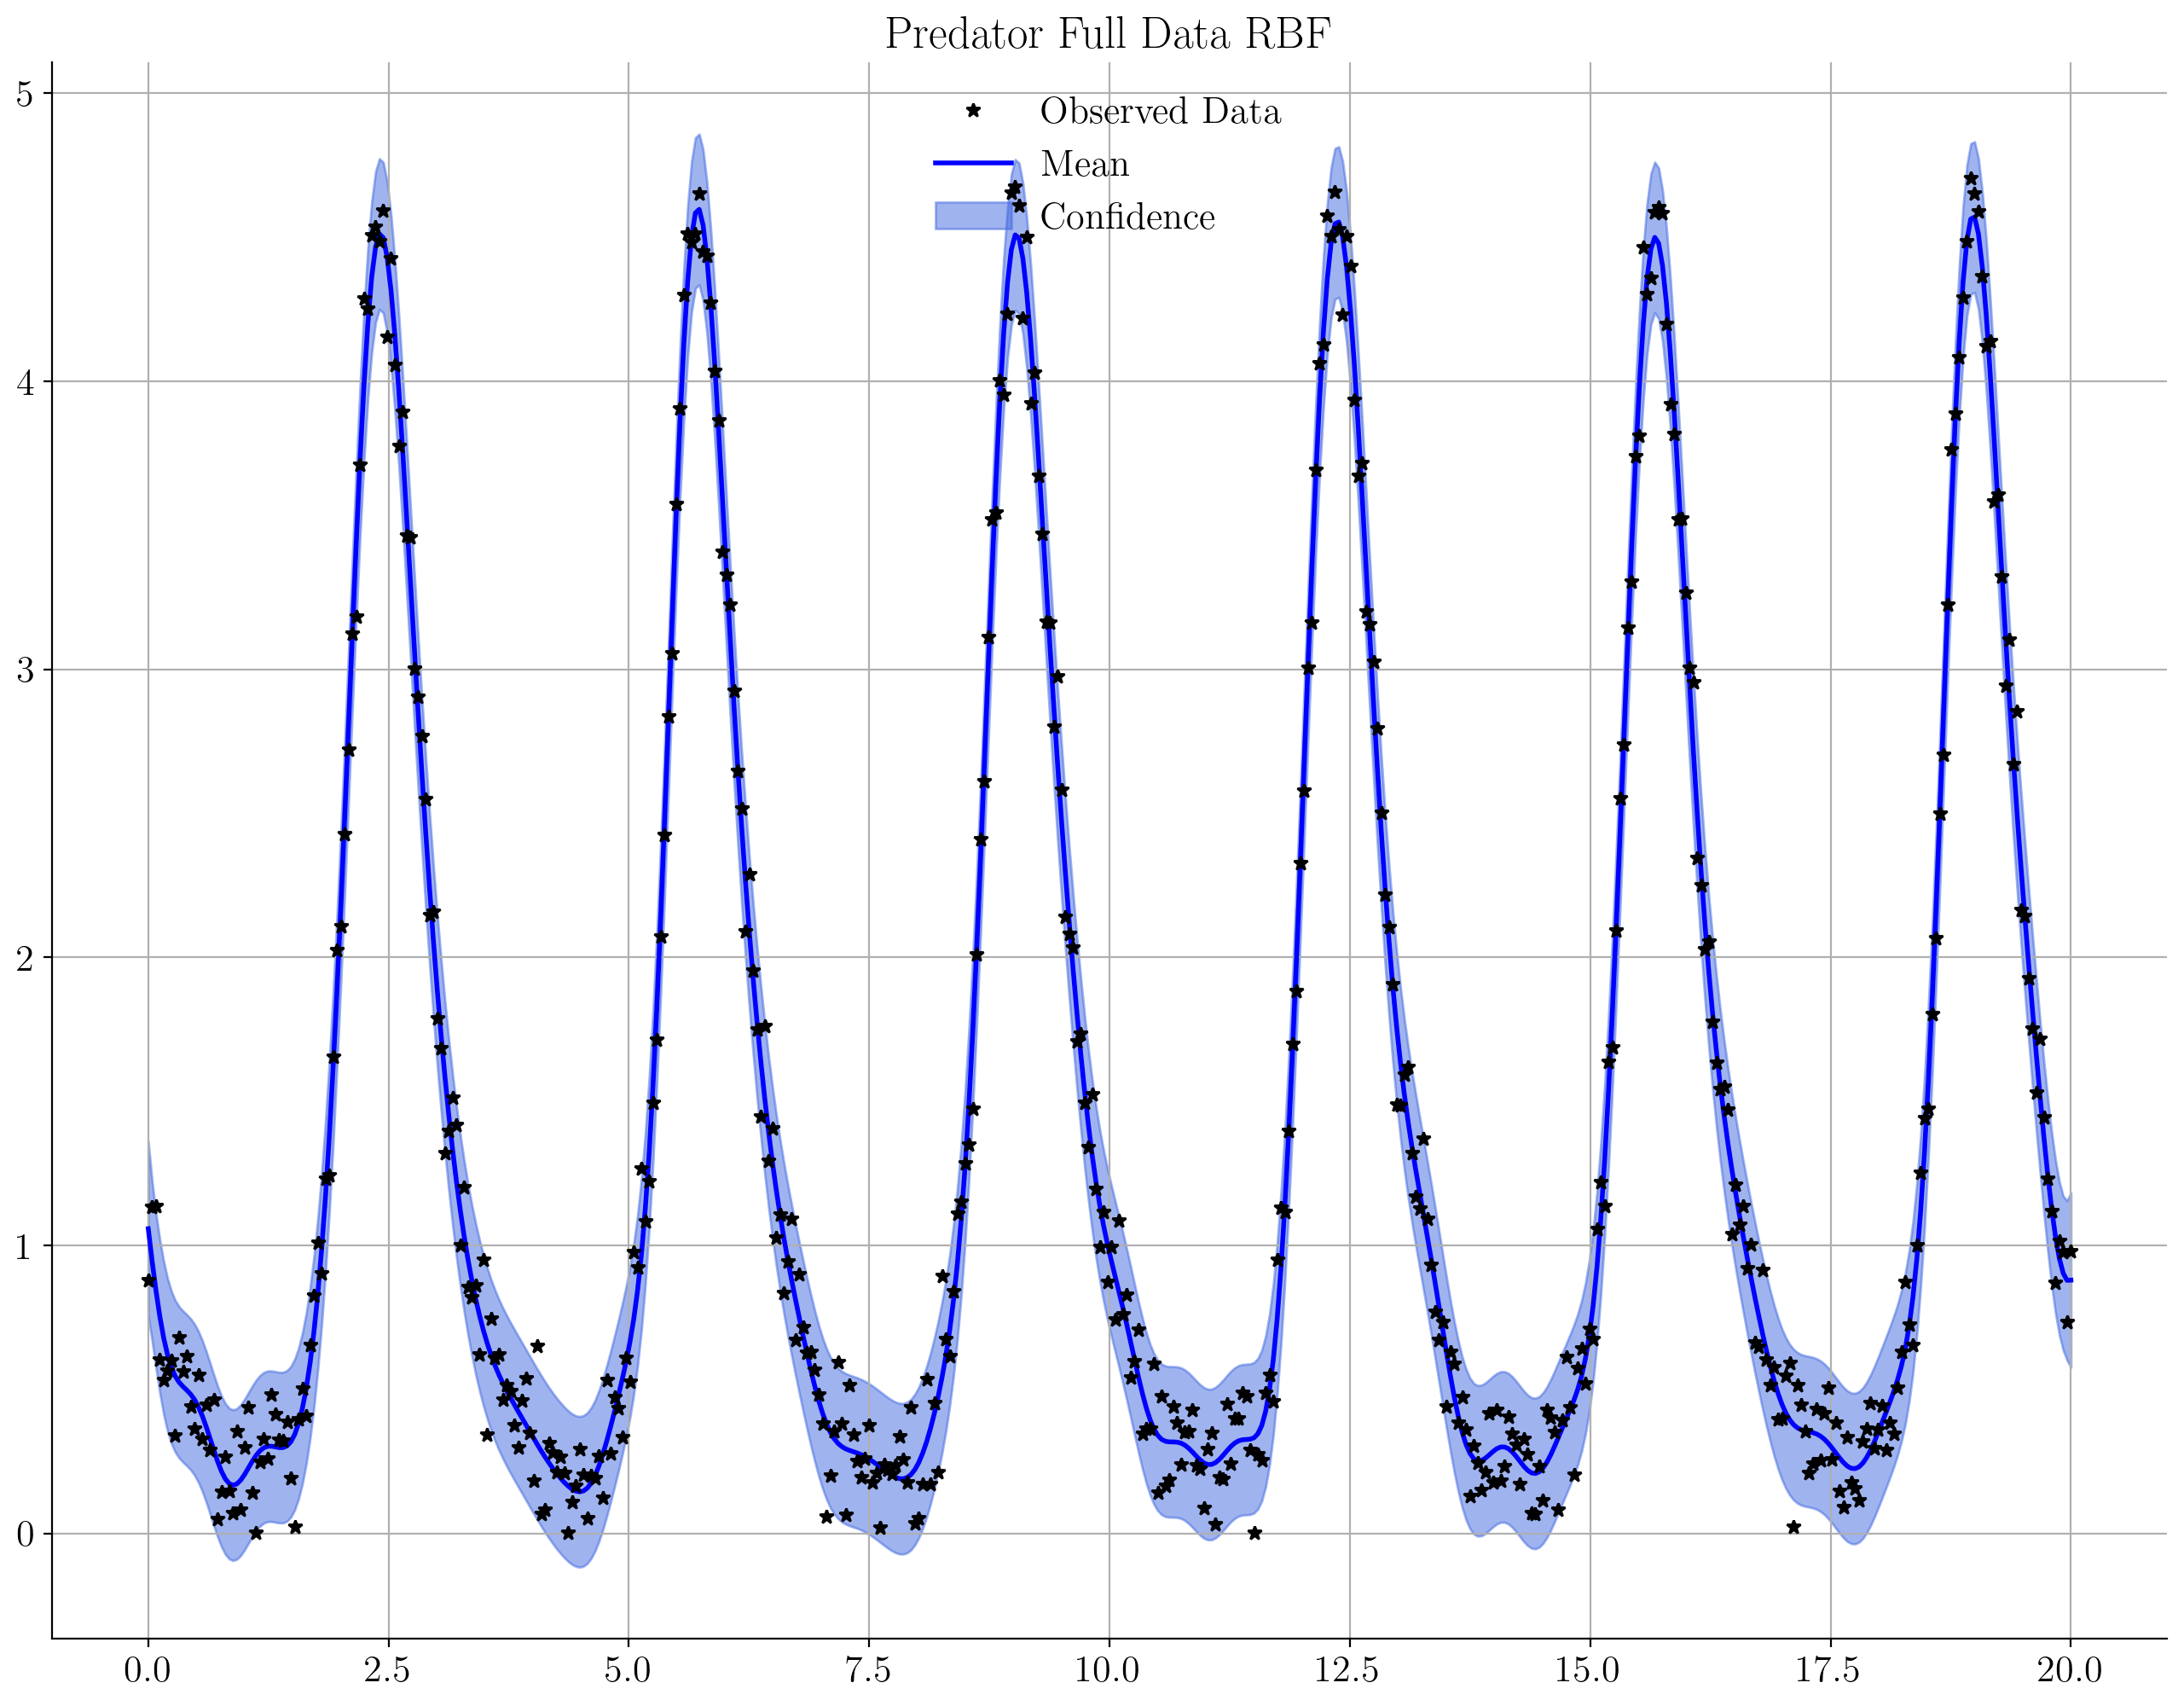

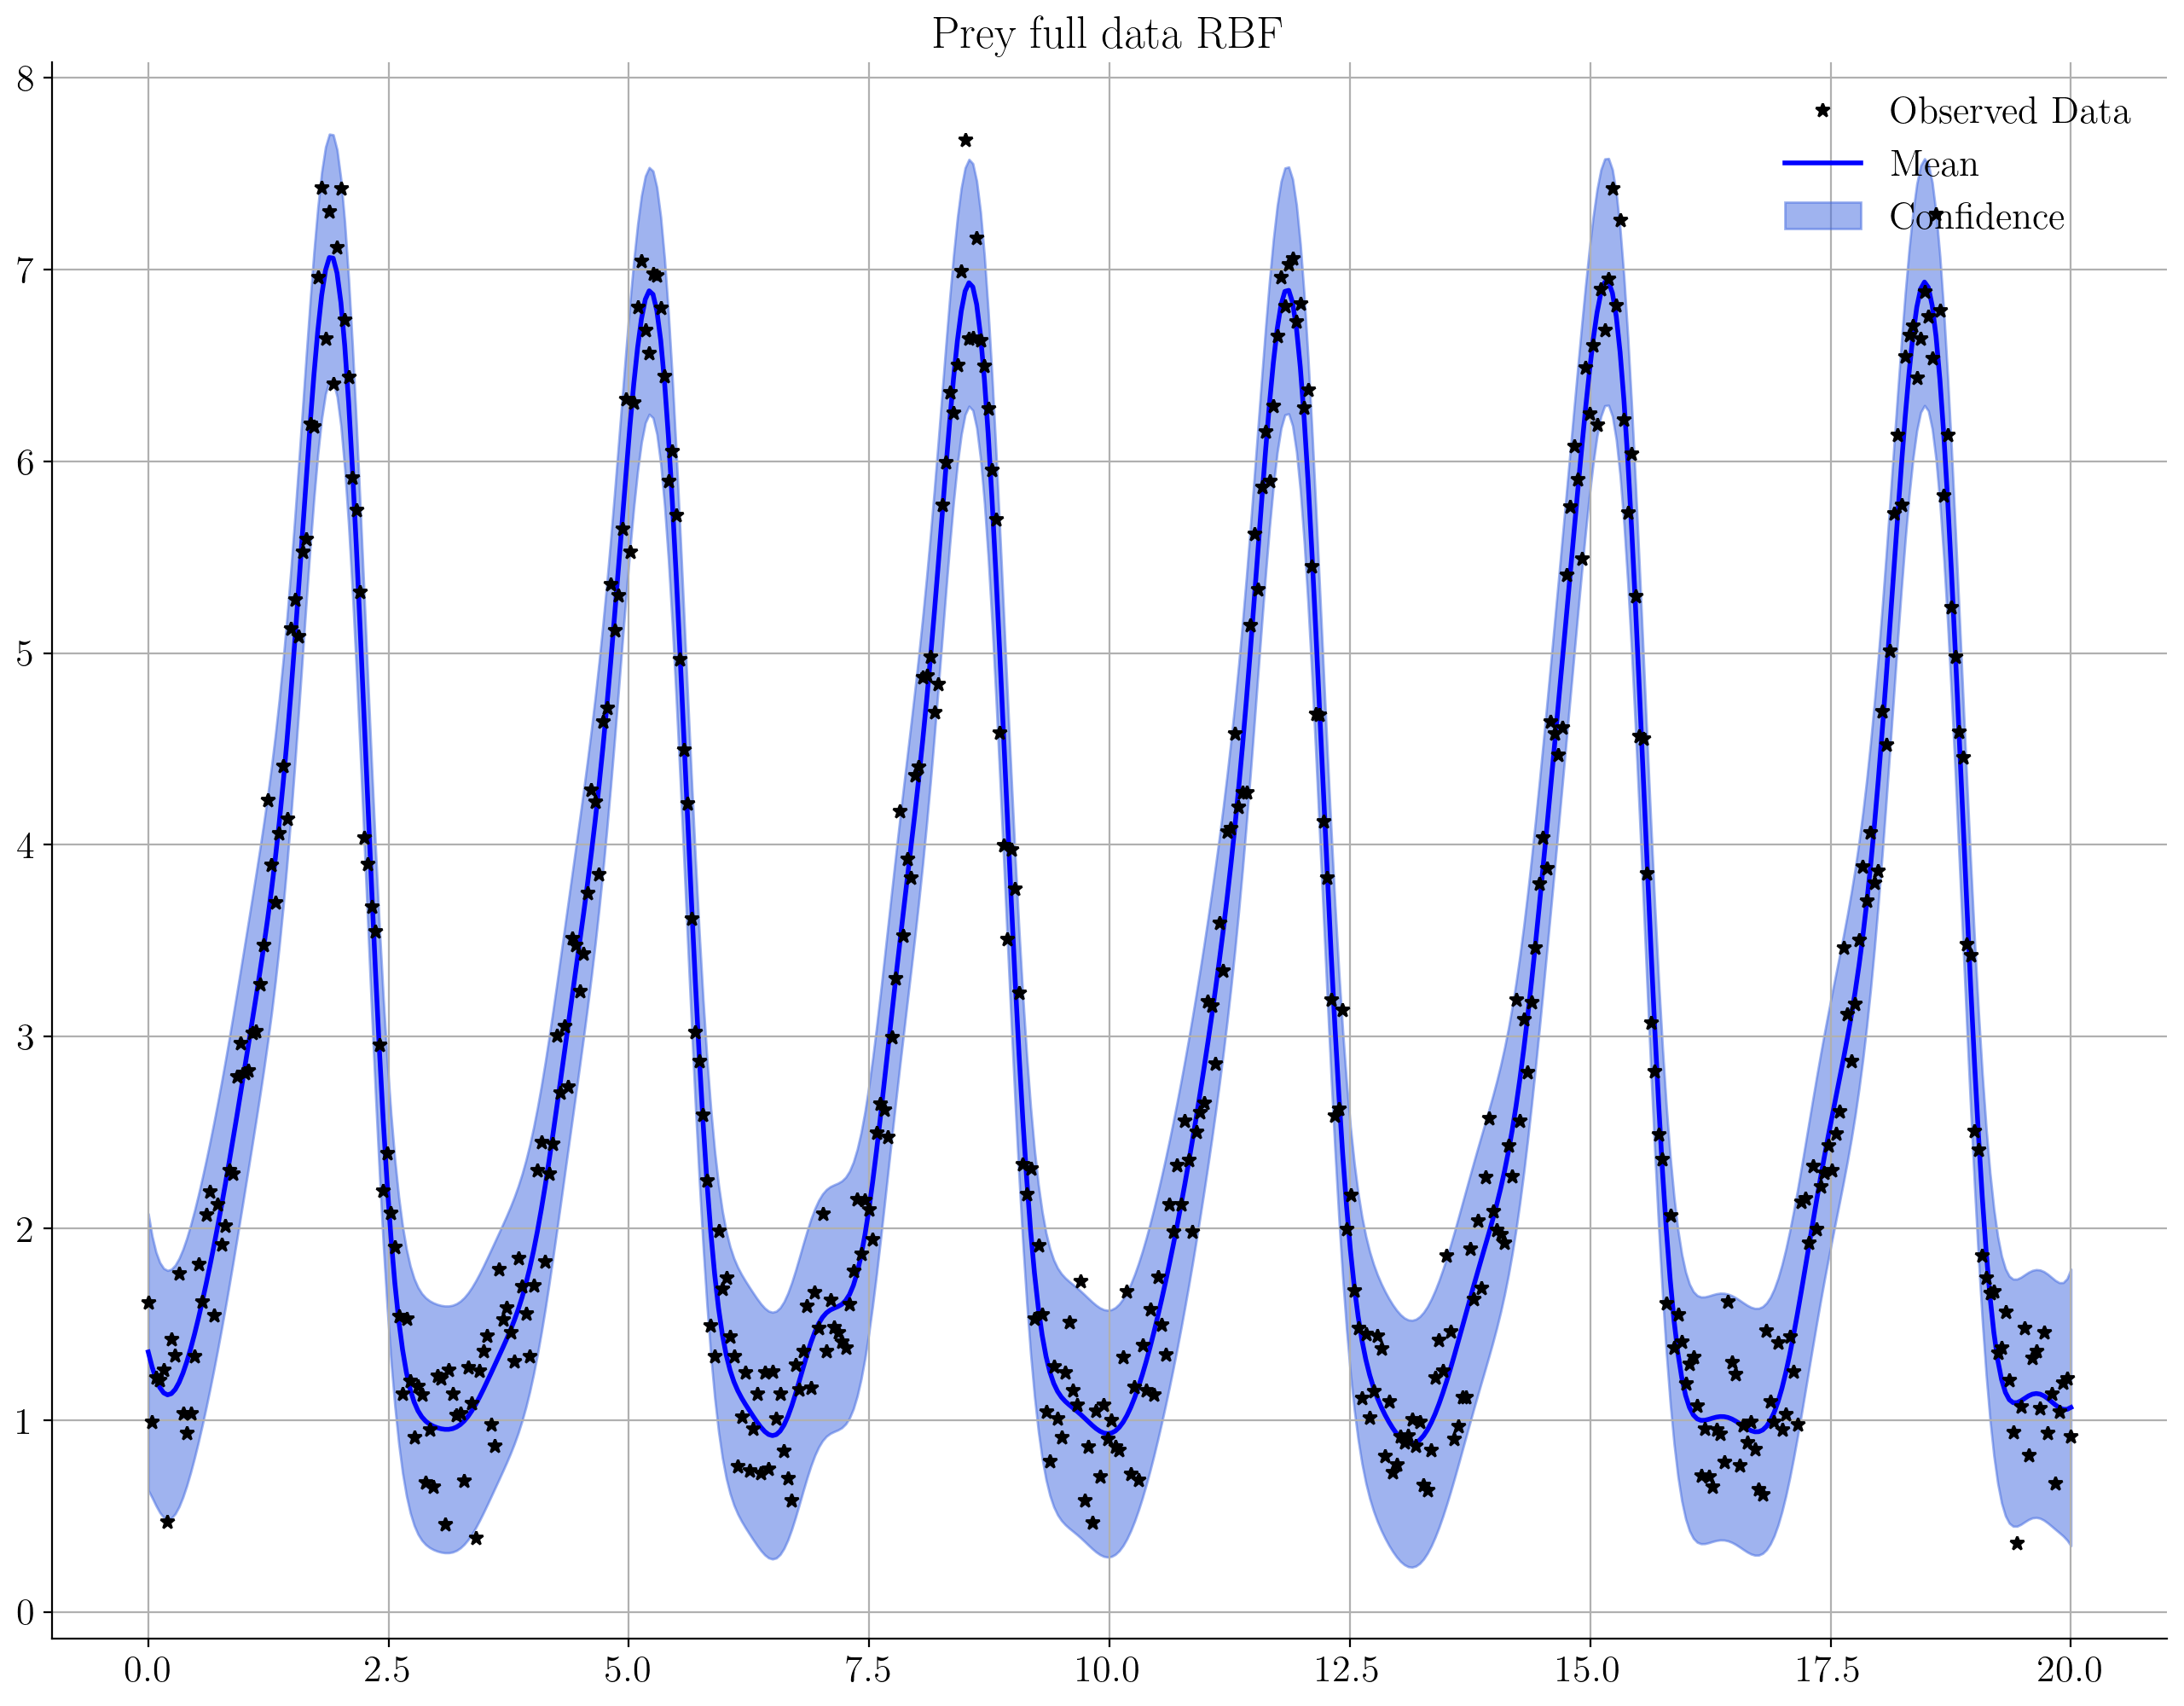

In [8]:
rbf_gp_pred = GP(time, predator_noisy, GaussianLikelihood(), ConstantMean(), ScaleKernel(RBFKernel())) 
rbf_gp_prey = GP(time, prey_noisy, GaussianLikelihood(), ConstantMean(), ScaleKernel(RBFKernel()))
train(rbf_gp_pred, time, predator_noisy)
train(rbf_gp_prey, time, prey_noisy)
display(time, predator_noisy, time, predator_noisy, rbf_gp_pred, "Predator Full Data RBF")
display(time, prey_noisy, time, prey_noisy, rbf_gp_prey, "Prey full data RBF")

### Test Uniformly Sparsified

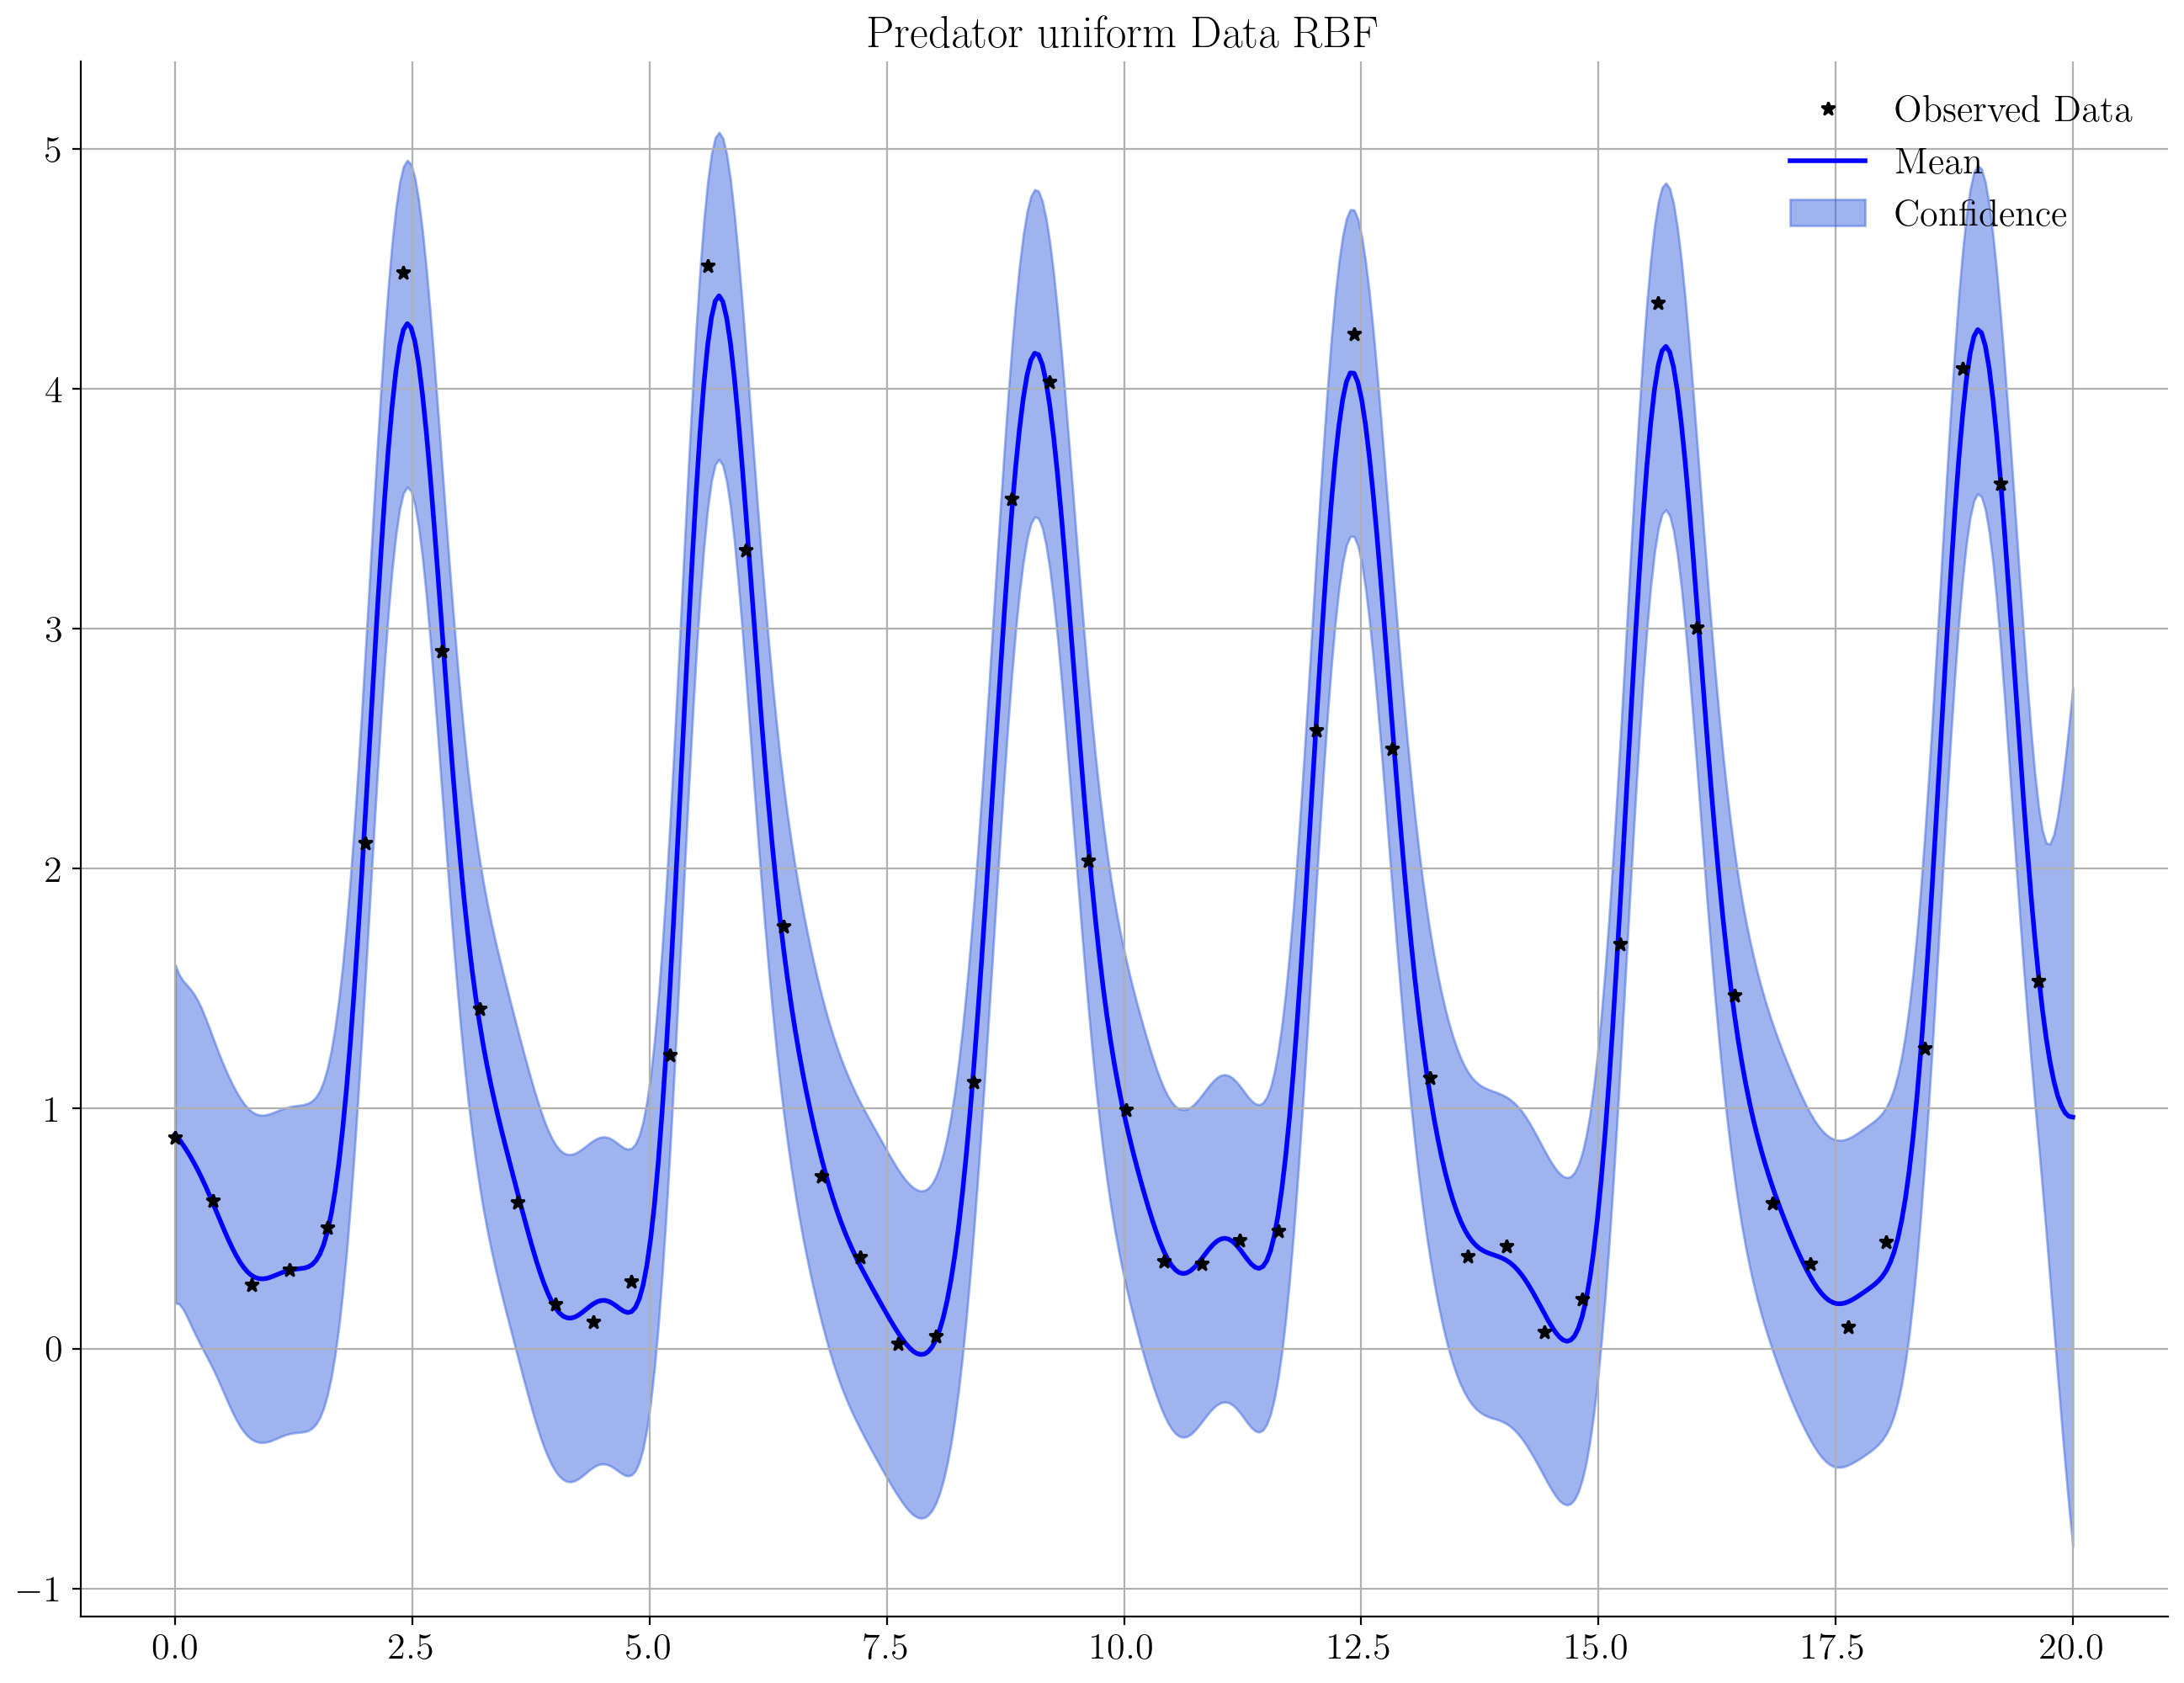

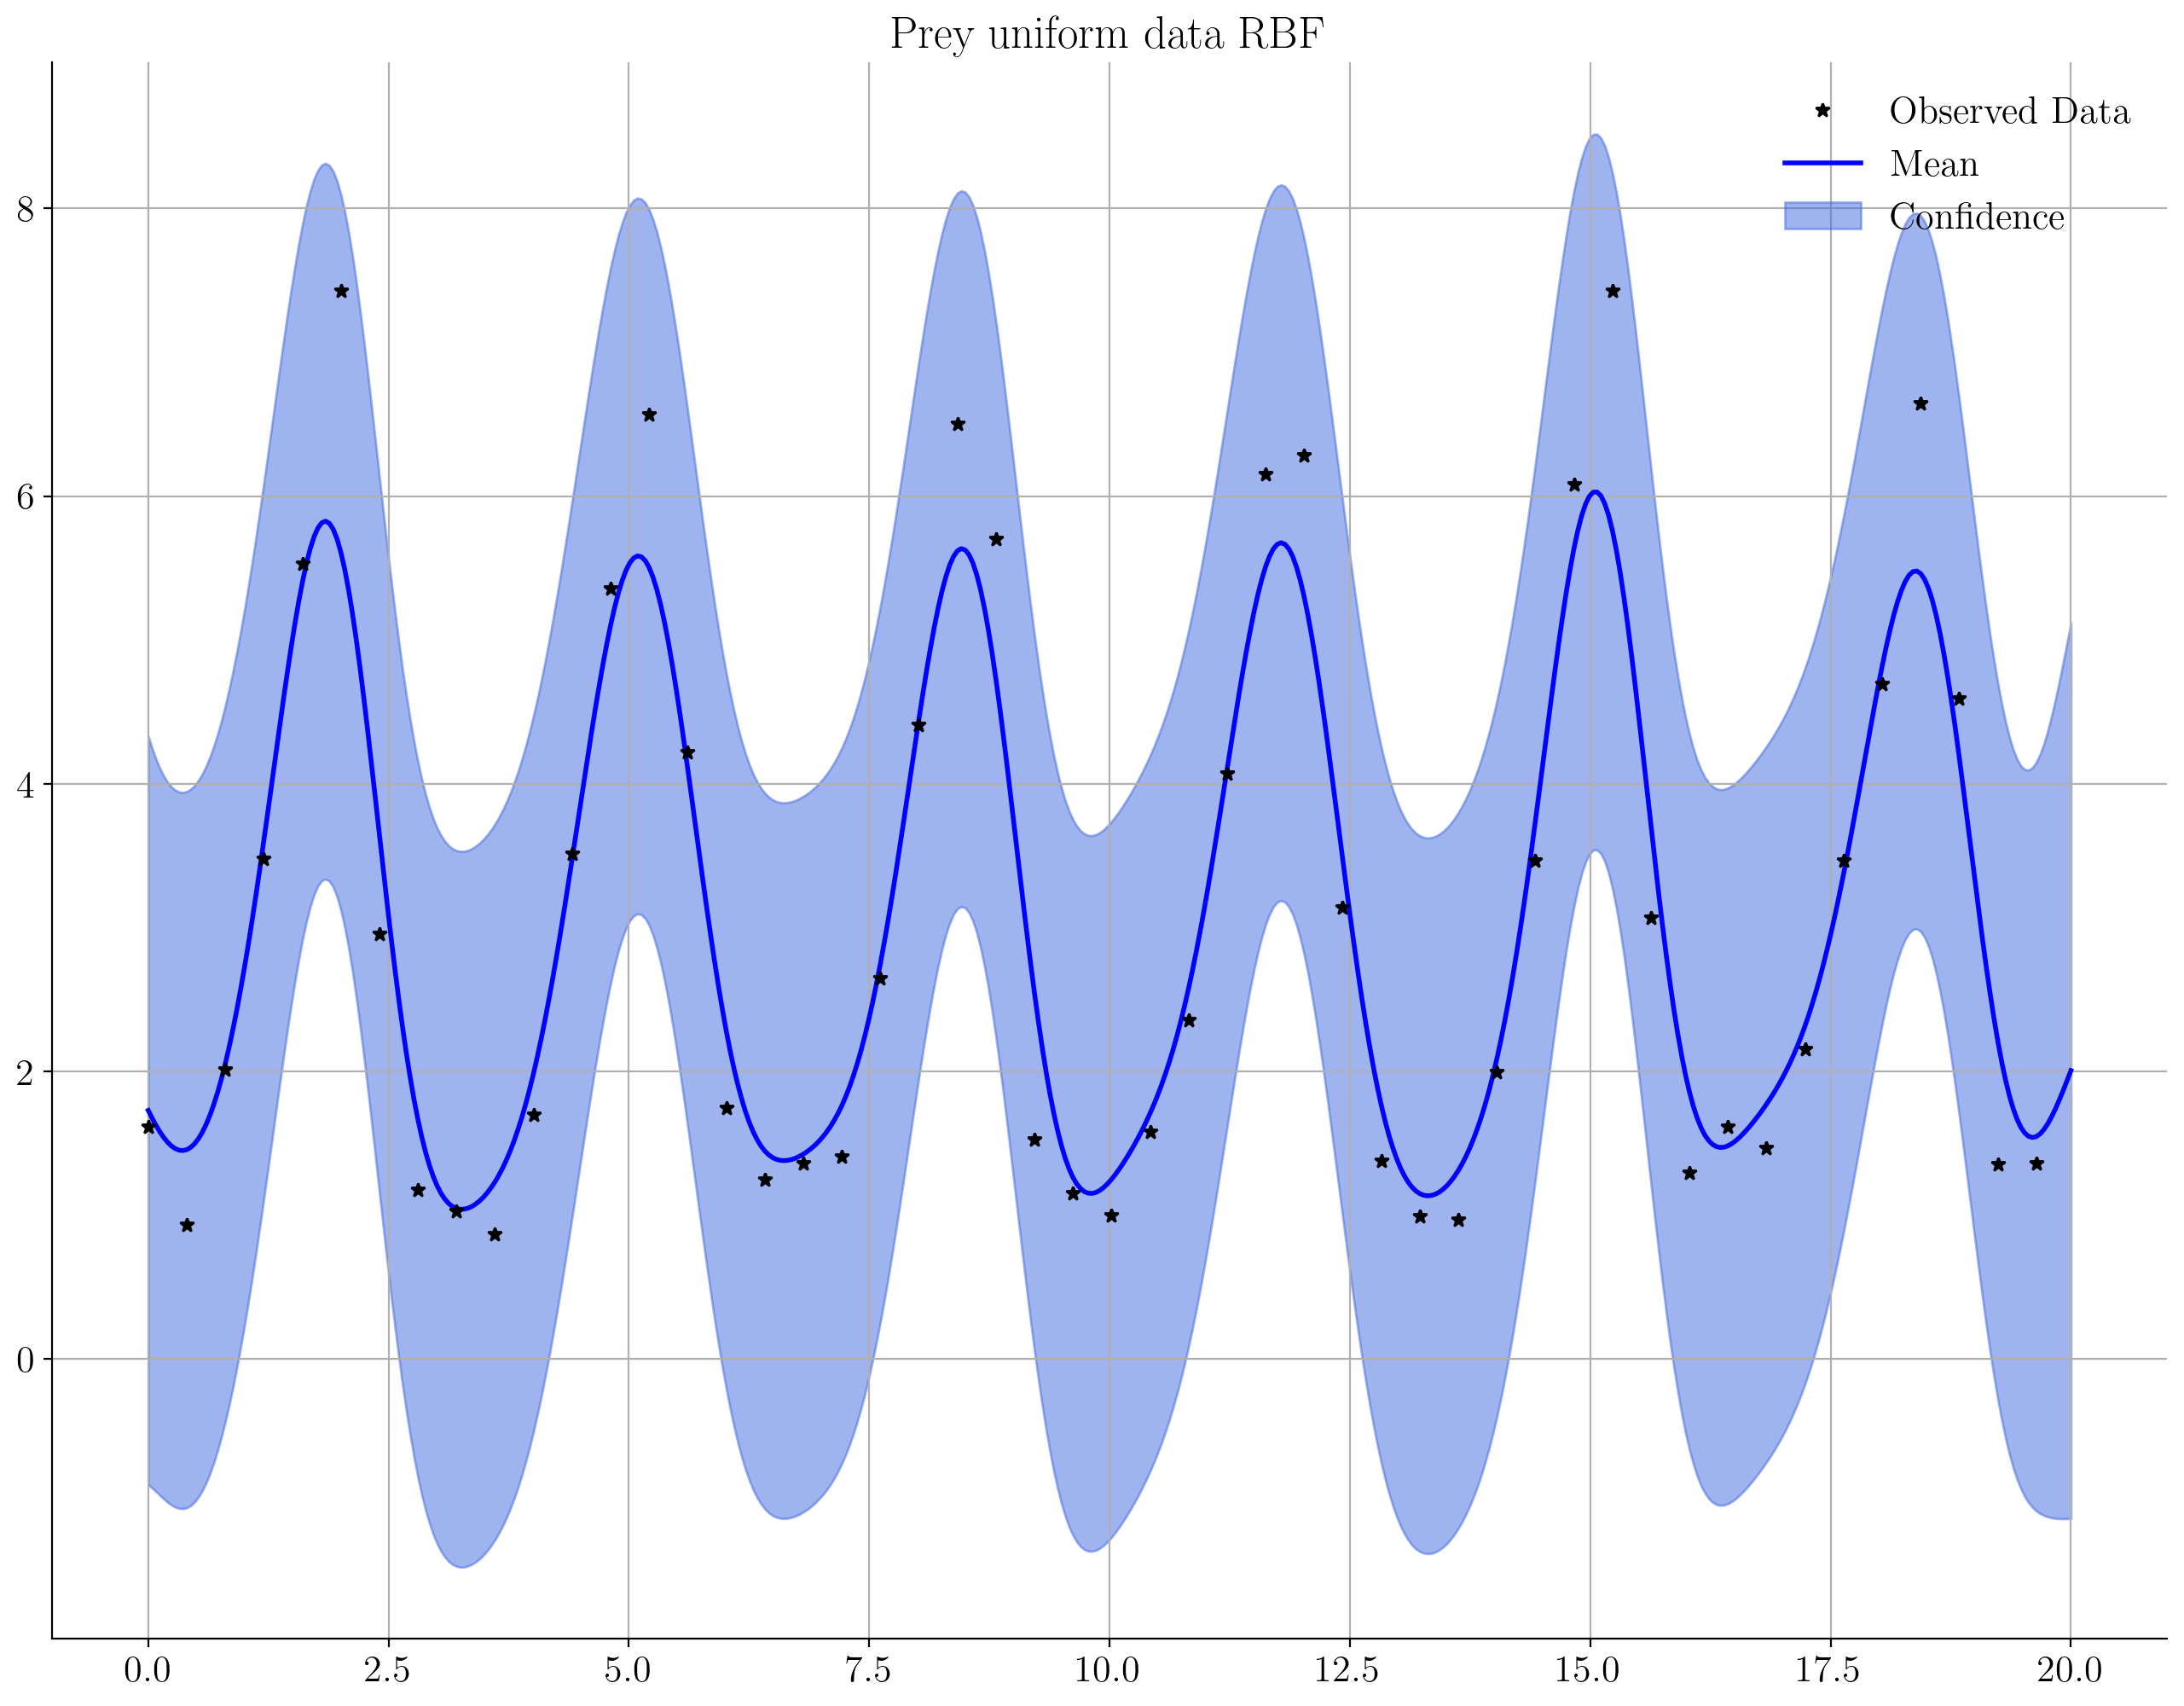

In [9]:
time_uniform, predator_noisy_uniform =  uniformly_sparsify(time, predator_noisy)
time_uniform, prey_noisy_uniform = uniformly_sparsify(time, prey_noisy)

rbf_gp_pred = GP(time_uniform, predator_noisy_uniform, GaussianLikelihood(), ConstantMean(), ScaleKernel(RBFKernel())) 
rbf_gp_prey = GP(time_uniform, prey_noisy_uniform, GaussianLikelihood(), ConstantMean(), ScaleKernel(RBFKernel()))
train(rbf_gp_pred, time_uniform, predator_noisy_uniform)
train(rbf_gp_prey, time_uniform, prey_noisy_uniform)
display(time_uniform, predator_noisy_uniform, time, predator_noisy, rbf_gp_pred, "Predator uniform Data RBF")
display(time_uniform, prey_noisy_uniform, time, prey_noisy, rbf_gp_prey, "Prey uniform data RBF")

### Randomly Sparsify

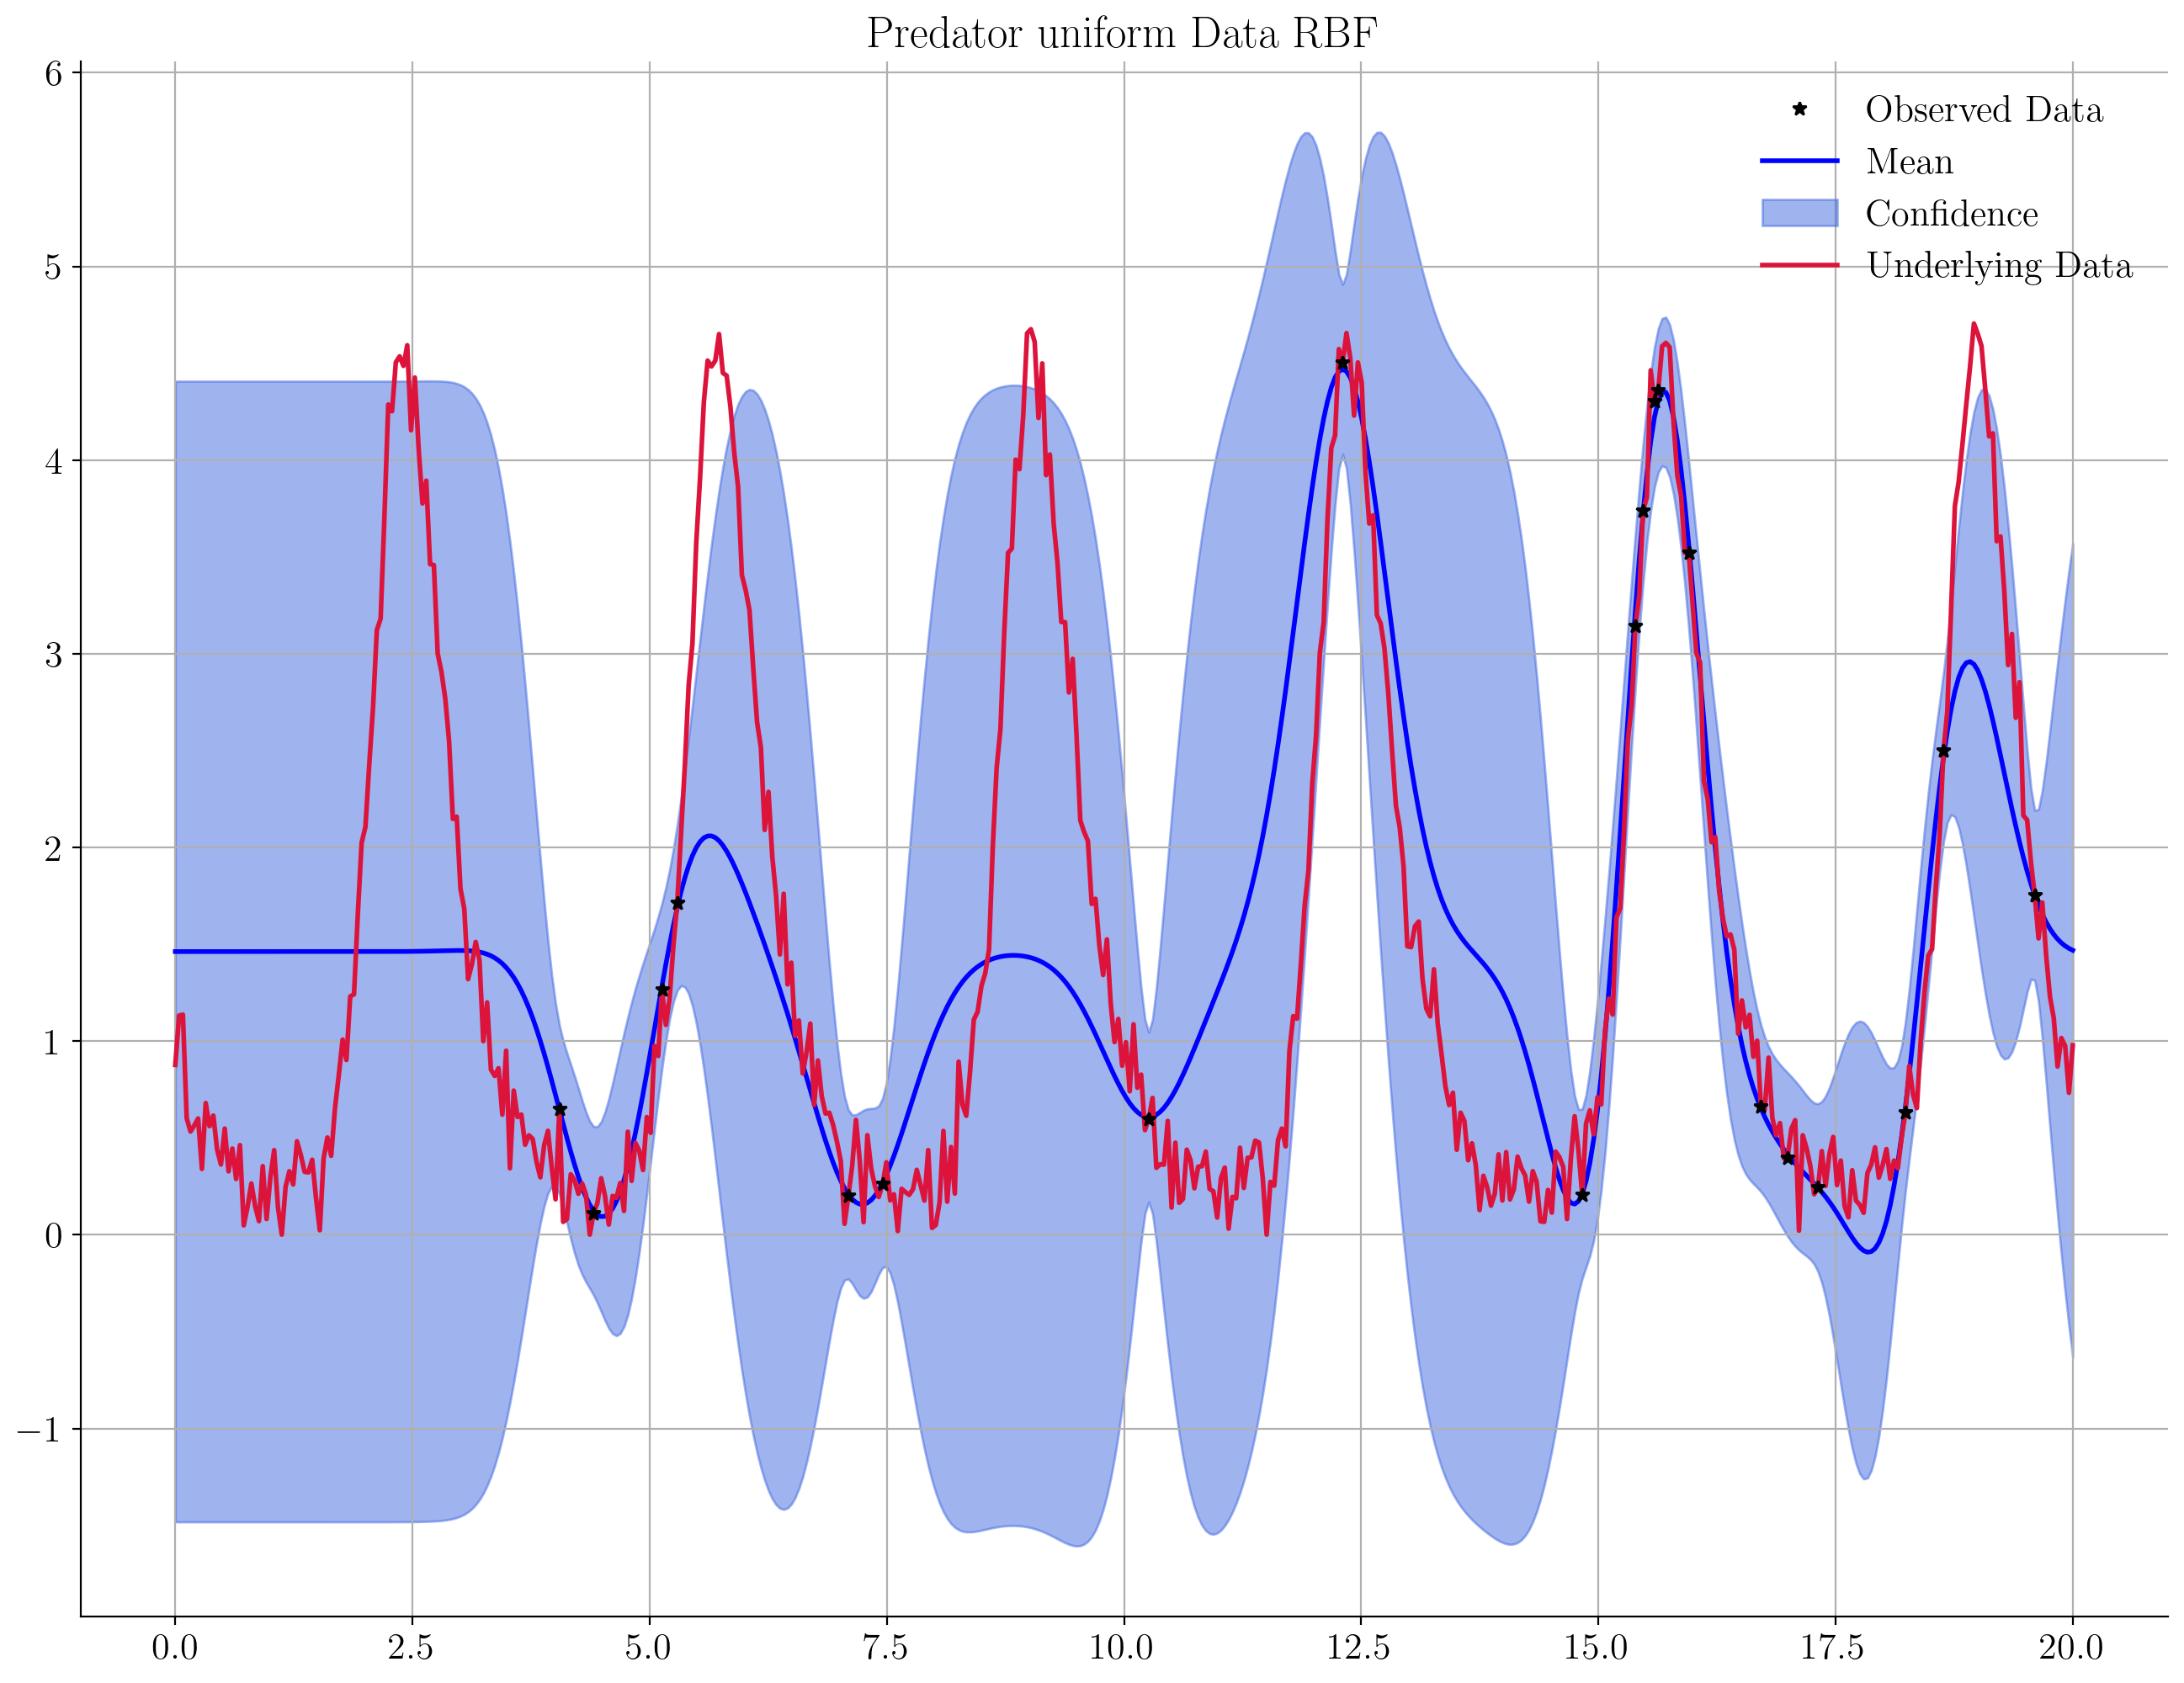

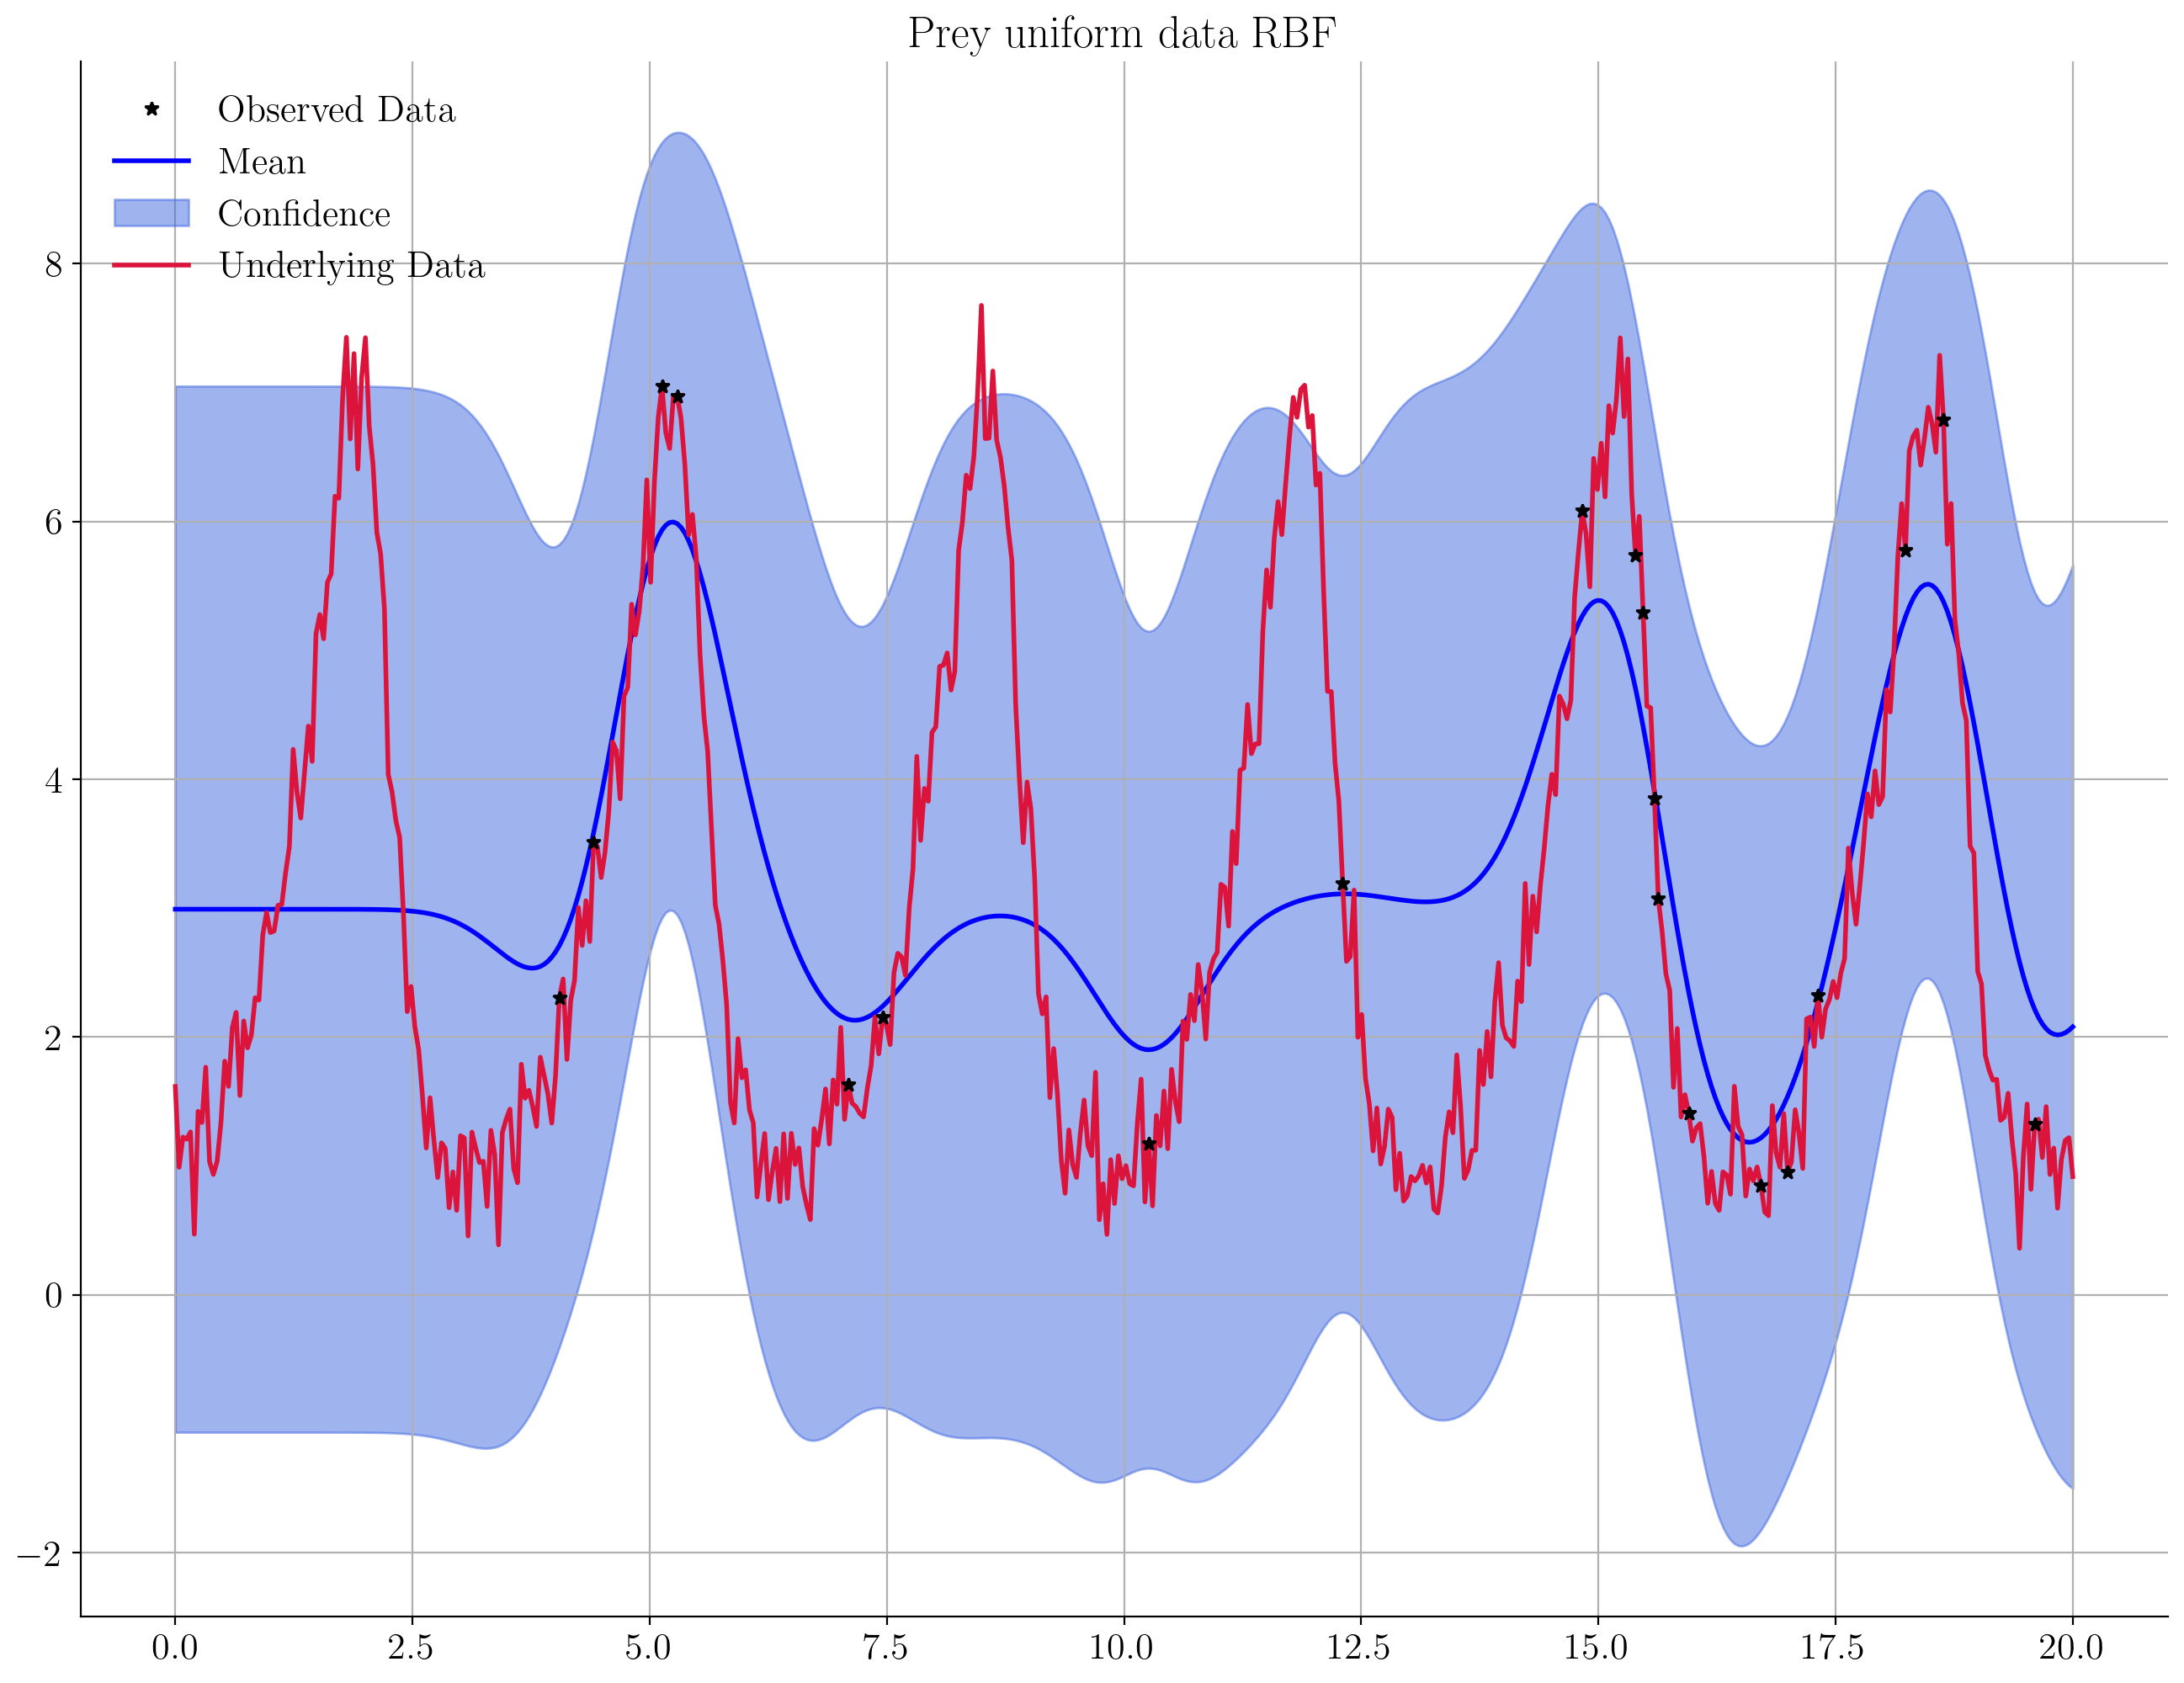

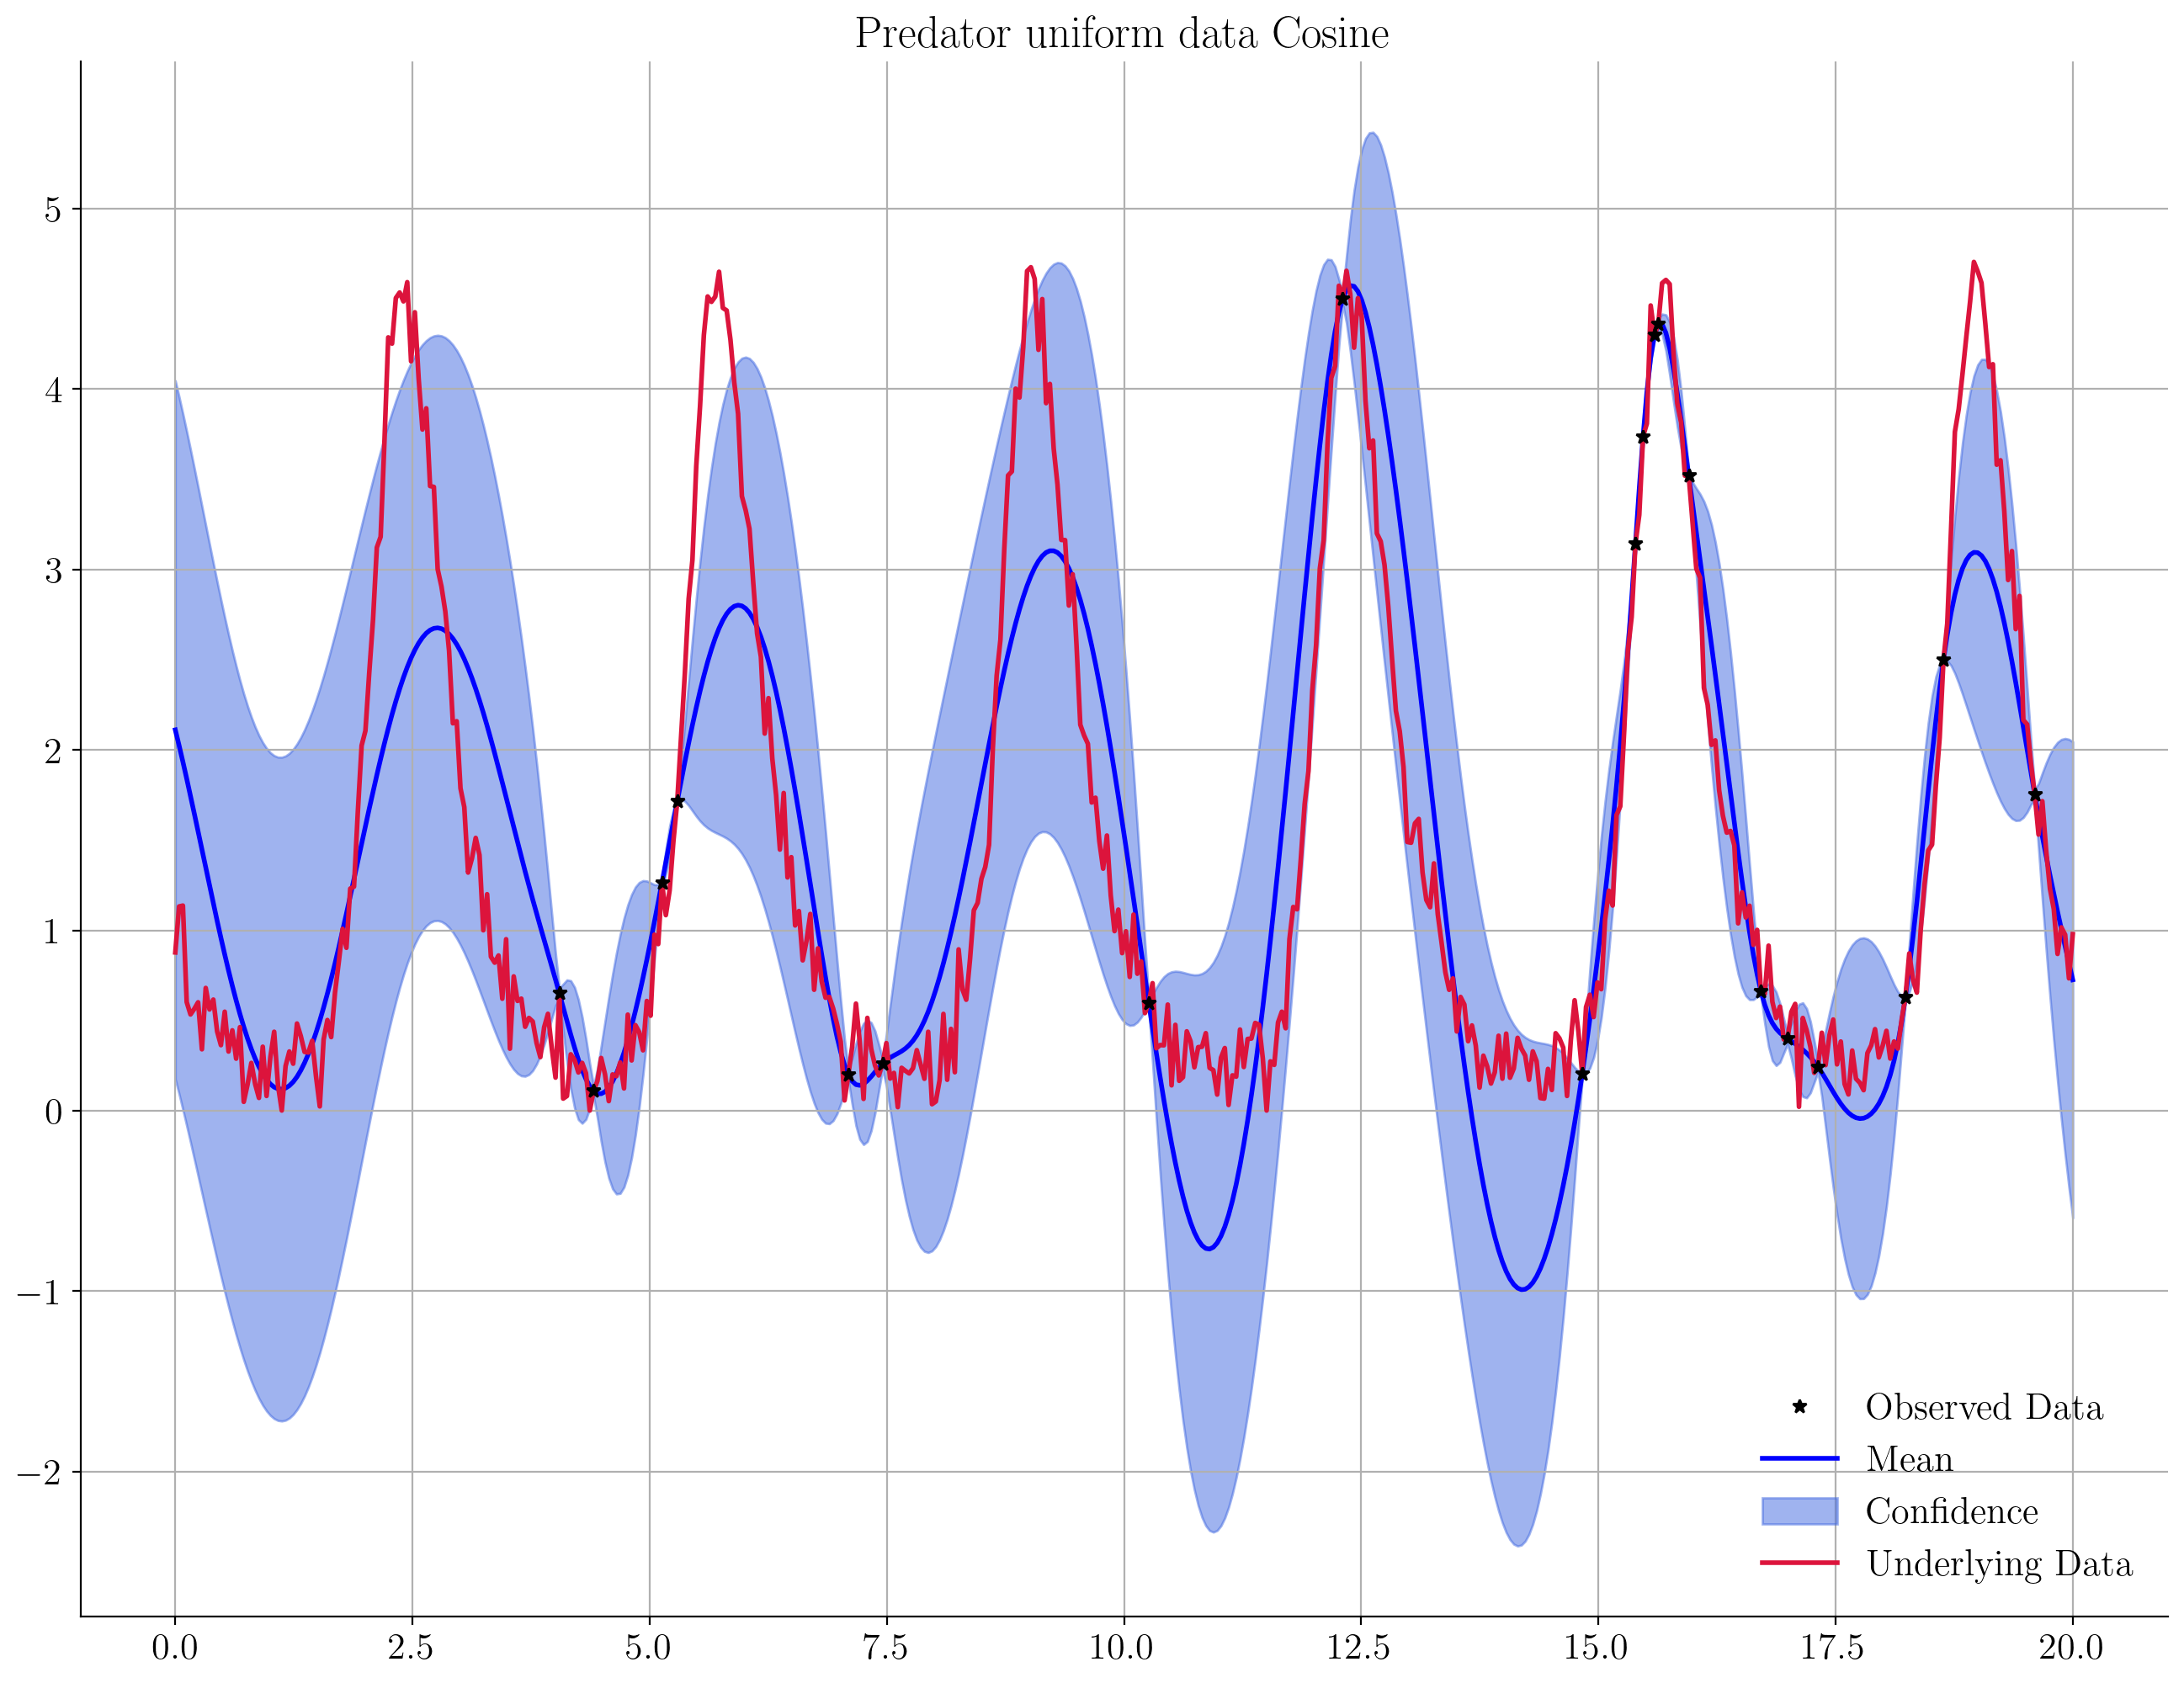

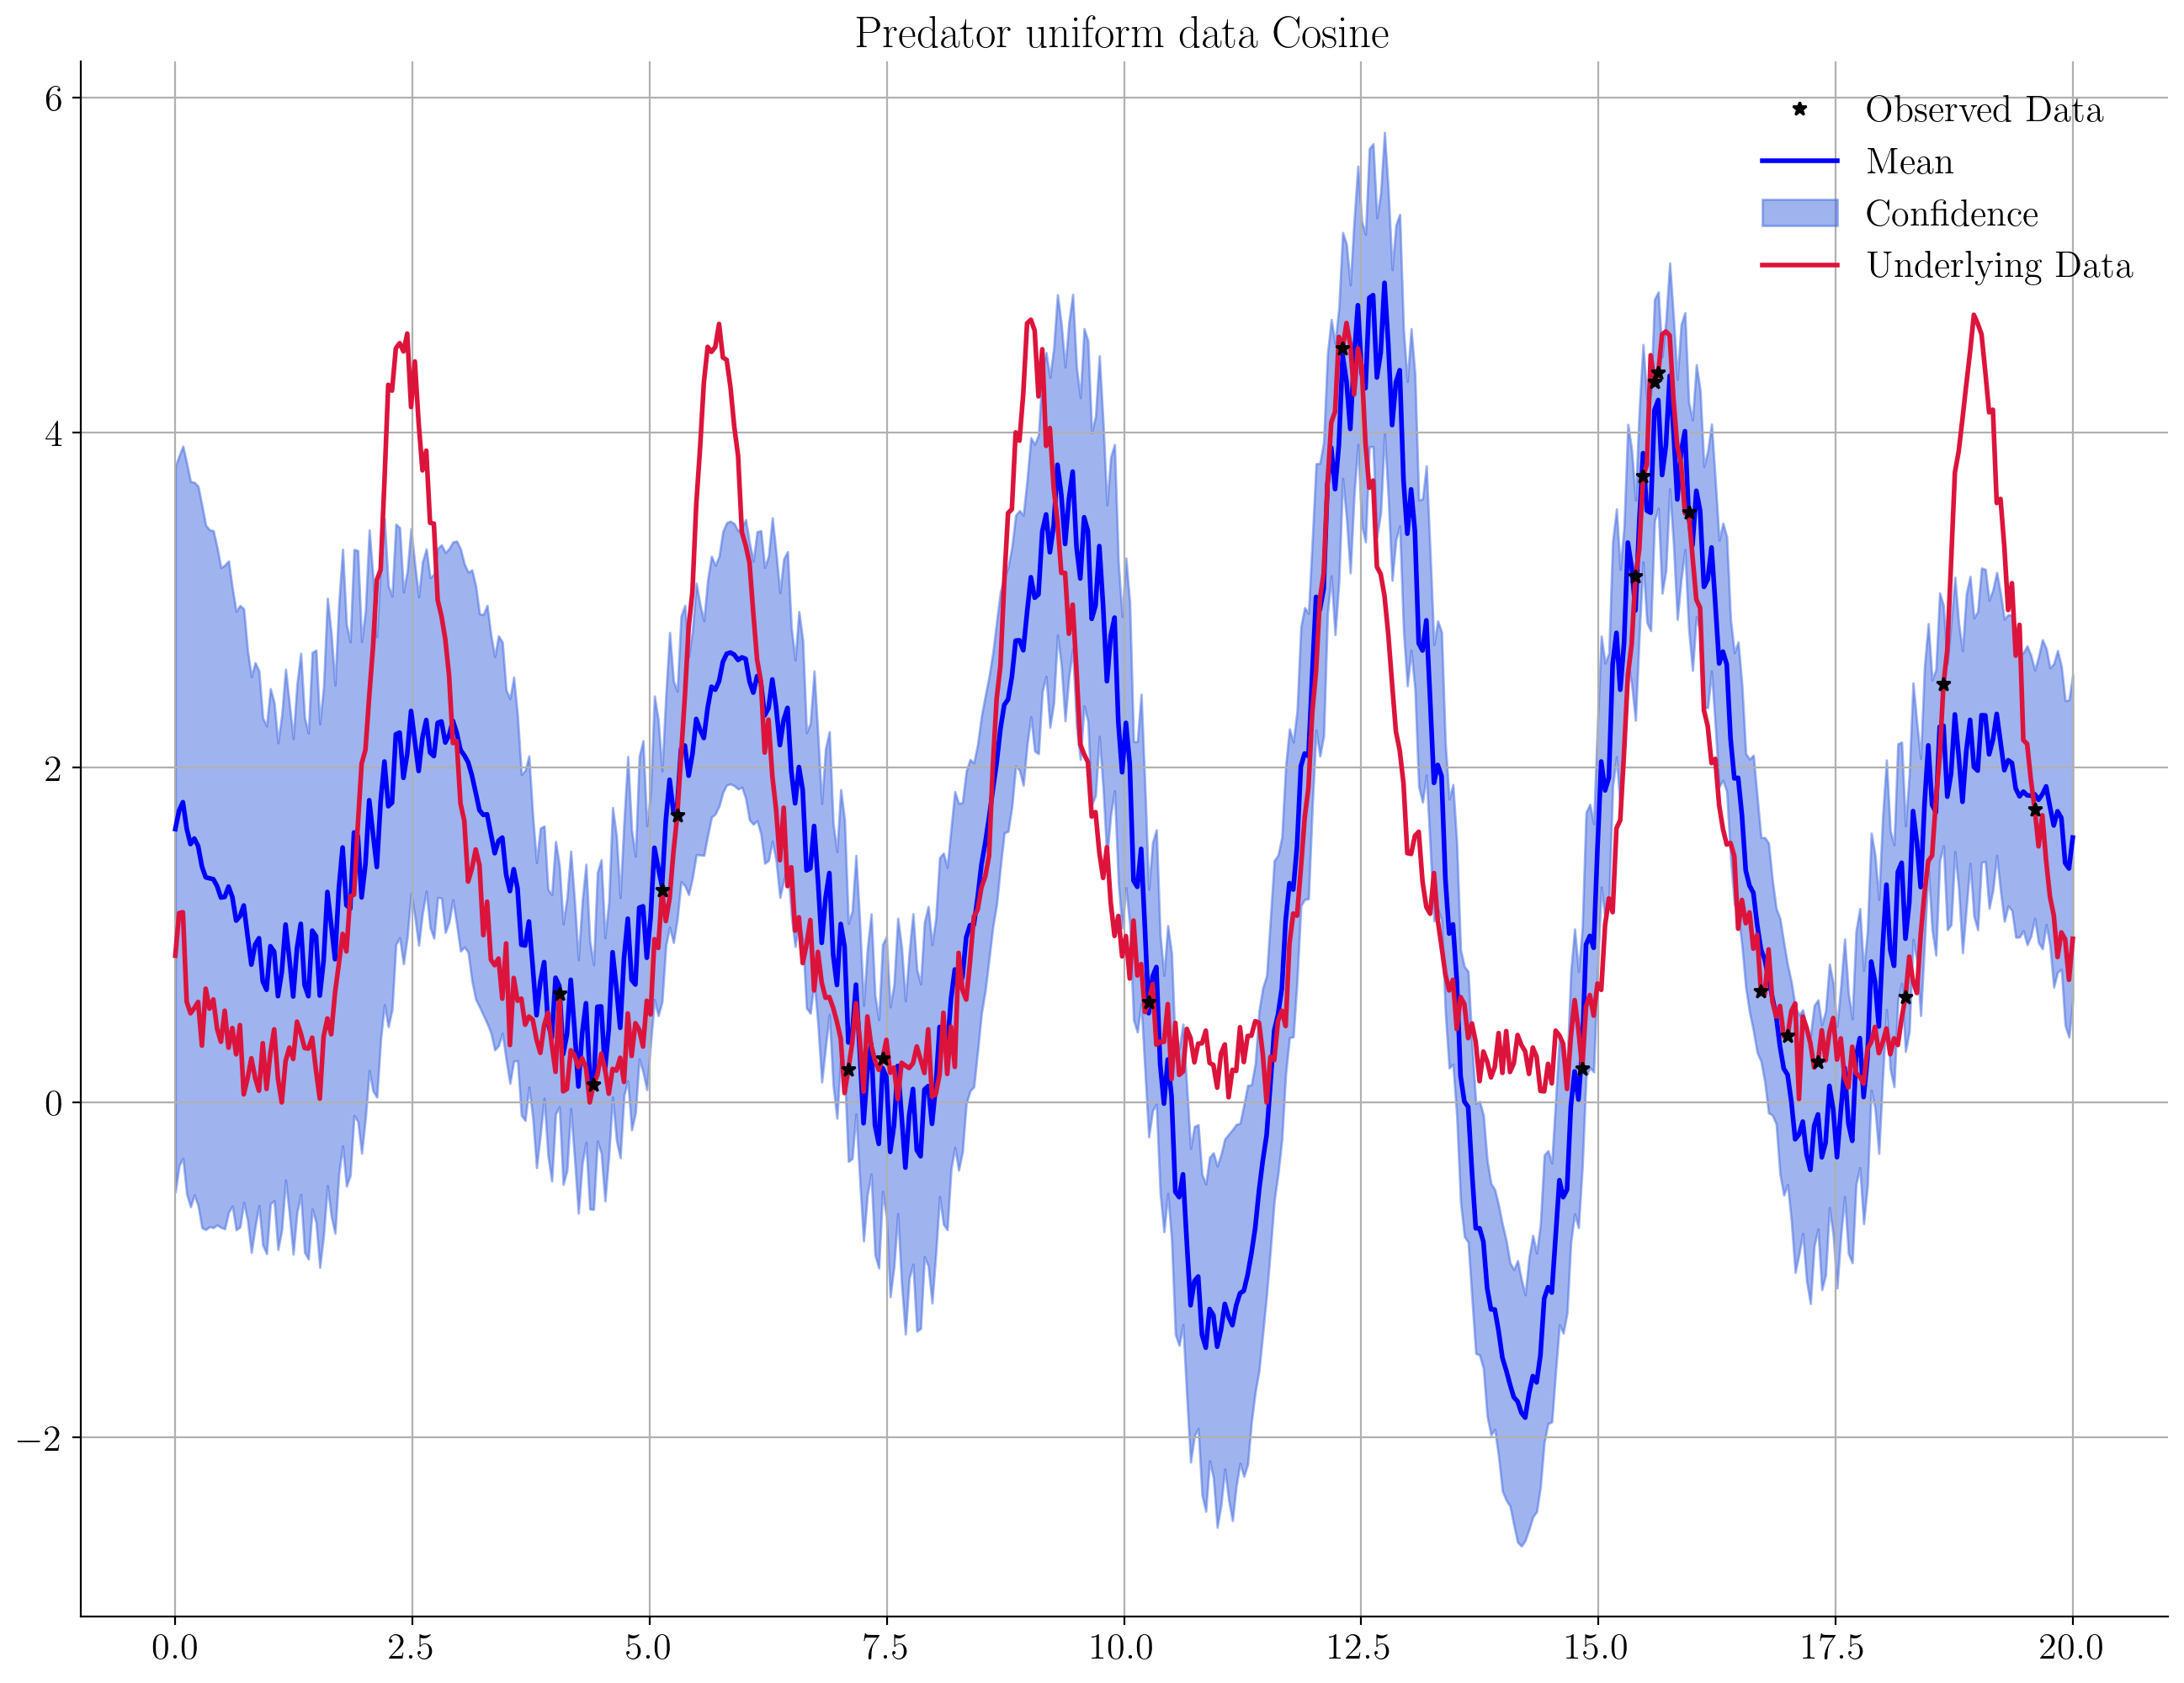

In [12]:
time_random, predator_noisy_random, prey_noisy_random = randomly_sparsify(time, predator_noisy, prey_noisy, num_points=20)
type(time_random), predator_noisy_random.shape, prey_noisy_random.shape

class SpectralMixtureGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(SpectralMixtureGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.SpectralMixtureKernel(num_mixtures=4)
        self.covar_module.initialize_from_data(train_x, train_y)

    def forward(self,x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

rbf_gp_pred = GP(time_random, predator_noisy_random, GaussianLikelihood(), ConstantMean(), ScaleKernel(RBFKernel())) 
rbf_gp_prey = GP(time_random, prey_noisy_random, GaussianLikelihood(), ConstantMean(), ScaleKernel(RBFKernel()))
cosine_gp_pred = GP(time_random, predator_noisy_random, GaussianLikelihood(), ConstantMean(), ScaleKernel(CosineKernel()*RQKernel()))
spectral_gp = SpectralMixtureGPModel(time_random, predator_noisy_random, GaussianLikelihood())
train(rbf_gp_pred, time_random, predator_noisy_random)
train(rbf_gp_prey, time_random, prey_noisy_random)
train(cosine_gp_pred, time_random, predator_noisy_random, training_iter=1028, lr=.0001)
train(spectral_gp, time_random, predator_noisy_random)
display(time_random, predator_noisy_random, time, predator_noisy, rbf_gp_pred, "Predator uniform Data RBF", True)
display(time_random, prey_noisy_random, time, prey_noisy, rbf_gp_prey, "Prey uniform data RBF", True)
display(time_random, predator_noisy_random, time, predator_noisy, cosine_gp_pred, "Predator uniform data Cosine", True)
display(time_random, predator_noisy_random, time, predator_noisy, spectral_gp, "Predator uniform data Cosine", True)

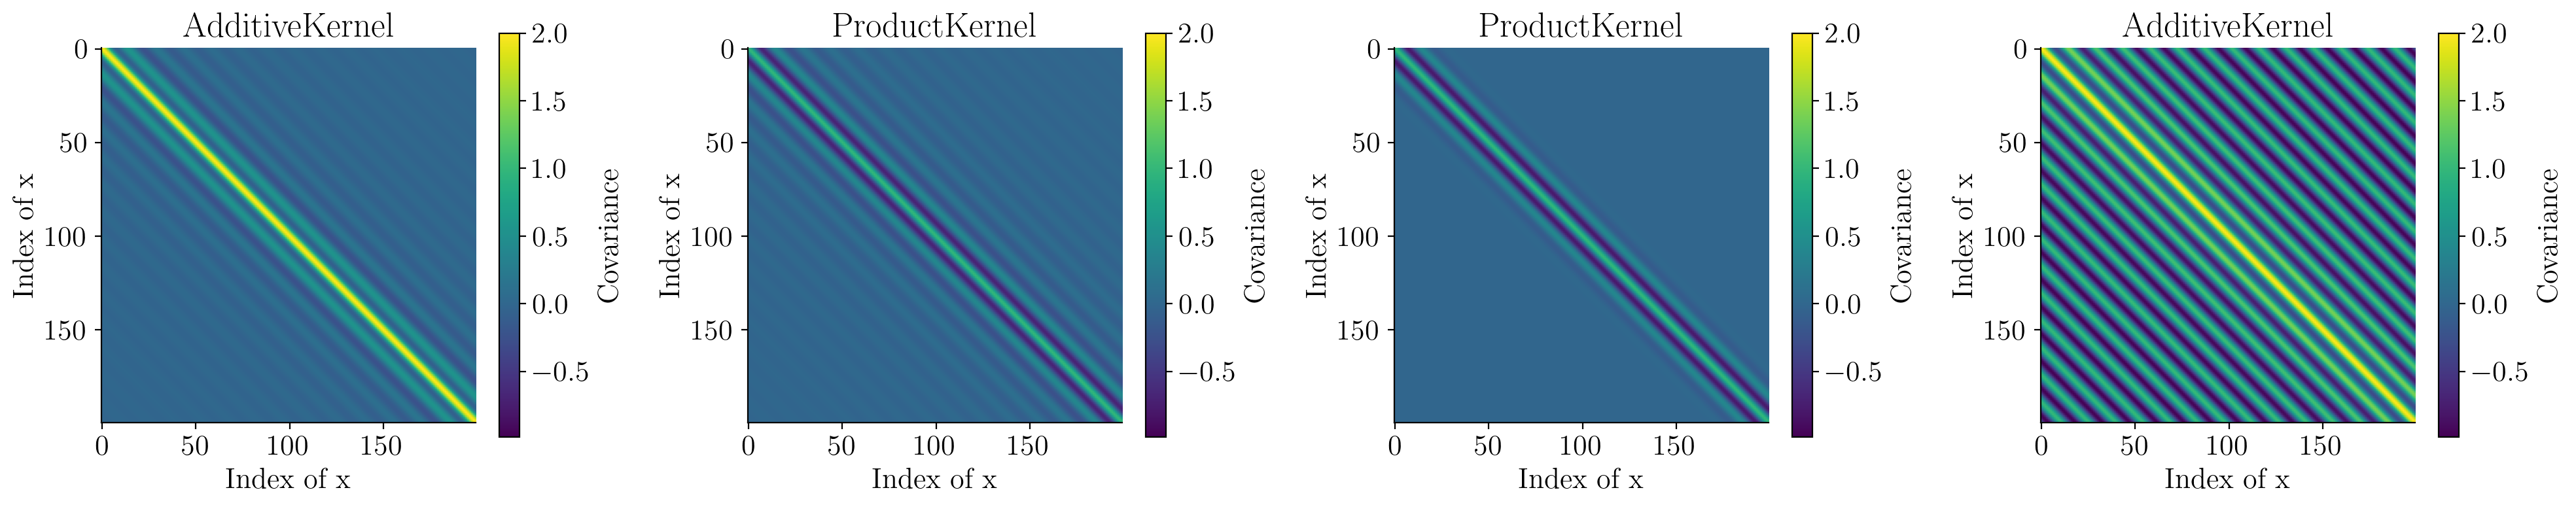

In [25]:
import torch
import gpytorch
import matplotlib.pyplot as plt

def visualize_covariance_matrices(kernels, x):
    """
    Compute and visualize the covariance matrix for inputs x under each kernel in 'kernels'.
    Plots them side-by-side in subplots, with a shared color scale for easy comparison.

    Parameters:
    -----------
    kernels : gpytorch.kernels.Kernel or list of gpytorch.kernels.Kernel
        A single GPyTorch kernel instance or a list of kernel instances (e.g., [RBFKernel(), MaternKernel(), ...]).
    x : torch.Tensor
        1D inputs as a tensor of shape [N, 1].
    """

    # 1. Ensure 'kernels' is a list
    if not isinstance(kernels, list):
        kernels = [kernels]

    # 2. Compute all covariance matrices
    cov_matrices = []
    for kernel in kernels:
        with torch.no_grad():
            cov_matrix = kernel(x, x).evaluate().cpu().numpy()
        cov_matrices.append(cov_matrix)

    # 3. Find global min and max to standardize color scale across subplots
    global_min = min(mat.min() for mat in cov_matrices)
    global_max = max(mat.max() for mat in cov_matrices)

    # 4. Create subplots
    n_kernels = len(kernels)
    fig, axes = plt.subplots(1, n_kernels, figsize=(5 * n_kernels, 4))

    # If there's only one kernel, axes is not a list; wrap it
    if n_kernels == 1:
        axes = [axes]

    # 5. Plot each covariance matrix
    for ax, kernel, cov_matrix in zip(axes, kernels, cov_matrices):
        im = ax.imshow(
            cov_matrix,
            cmap='viridis',
            origin='upper',
            vmin=global_min,  # Use global min
            vmax=global_max   # Use global max
        )
        ax.set_title(f'{kernel.__class__.__name__}')
        ax.set_xlabel('Index of x')
        ax.set_ylabel('Index of x')
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Covariance')

    plt.tight_layout()
    plt.show()

# 1. Define your 1D input points (e.g., from 1 to 20):
x = torch.linspace(1, 20, 200).unsqueeze(-1)  # shape: [20, 1]

# 2. Create a kernel (here, an RBF kernel for demonstration):
rbf_kernel = (CosineKernel() * RQKernel()) + RBFKernel()
kernel2 = CosineKernel() * RQKernel()
kernel3 = CosineKernel() * RBFKernel().initialize(lengthscale=1)
kernel4 = CosineKernel() + RQKernel()

# 3. Visualize the covariance matrix for these inputs:
visualize_covariance_matrices([rbf_kernel, kernel2, kernel3, kernel4], x)